# [1] Imports & Setup (Dual Run Modes)


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# [1] Setup & Imports
# ─────────────────────────────────────────────────────────────────────────────
import os
import sys
import glob
import json
import shutil
from pathlib import Path
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.io import savemat

# Repo root on path
repo_root = Path.cwd().resolve()
while repo_root.name and repo_root.name not in ("EveryMotor", "NvidiaNemo"):
    repo_root = repo_root.parent
emach_root = repo_root / "eMach"
if str(emach_root) not in sys.path:
    sys.path.insert(0, str(emach_root))
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f"Repository Root: {repo_root}")
print(f"eMach Root: {emach_root}")



Repository Root: D:\KangDH\EveryMotor
eMach Root: D:\KangDH\EveryMotor\eMach


# [2] 모터 모델 및 실행 모드 설정


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# [2] Configuration: Model Scale & Run Mode Selection
# ─────────────────────────────────────────────────────────────────────────────
# Define motor file paths for each local/remote configuration
# (Update these paths to match your local folders on different machines)
MOTOR_FILES = {
    'Ref': r"D:\KDH\simVary\e10_6TSweep\refModel\e10Turn6V261.mot",
    'HalfSC': r"D:\KDH\simVary\e10_6TSweep\SLFEA_Half\e10Turn6V261SLFEA_Half.mot",
    'SC': r"D:\KDH\simVary\e10_6TSweep\SLFEA\e10Turn6V261SLFEA.mot"
}
json_summary_path = Path(r"D:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\map_exports\Ref\JEET_ACLoss_Ref_Map_Summary.json")
out_dir = json_summary_path.parent

MODEL_SCALE = 'Ref'  # Options: 'Ref' (k_Radial=1.0), 'HalfSC' (k_Radial=1.5), 'SC' (k_Radial=2.0)
RUN_FEA_SWEEP = True    # True: Run FEA inside Motor-CAD. False: Bypasses connection, loads JSON map only.
mat_summary_path = out_dir / f"JEET_ACLoss_{MODEL_SCALE}_Map_Summary.mat"
rbf_model_path = out_dir / f"AF_RBF_model_{MODEL_SCALE}.json"



In [ ]:

out_dir = Path("map_exports")
out_dir.mkdir(parents=True, exist_ok=True)

# ── 1. Path existence check for all Model Scales ─────────────────────────────
print("=== [Data & Model Path Existence Check] ===")
for scale in ['Ref', 'HalfSC', 'SC']:
    mot_p = MOTOR_FILES.get(scale)
    json_p = out_dir / f"JEET_ACLoss_{scale}_Map_Summary.json"
    
    mot_exists = Path(mot_p).exists() if mot_p else False
    json_exists = json_p.exists()
    
    print(f"[{scale}]")
    print(f"  - .mot file path: {mot_p}")
    print(f"    -> Exists? {'[YES]' if mot_exists else '[NO]'}")
    print(f"  - JSON summary:  {json_p}")
    print(f"    -> Exists? {'[YES]' if json_exists else '[NO]'}")
print("===========================================\n")


mot_file_path = MOTOR_FILES.get(MODEL_SCALE)
print(f"Selected Model Scale: {MODEL_SCALE}")
print(f"Target Motor File: {mot_file_path}")
print(f"FEA Sweep Execution: {'ENABLED' if RUN_FEA_SWEEP else 'DISABLED (Offline Mode)'}")

# Output summary paths
json_summary_path = out_dir / f"JEET_ACLoss_{MODEL_SCALE}_Map_Summary.json"
mat_summary_path = out_dir / f"JEET_ACLoss_{MODEL_SCALE}_Map_Summary.mat"
rbf_model_path = out_dir / f"AF_RBF_model_{MODEL_SCALE}.json"

# Convert to SI units (will be updated dynamically if connected, else uses fallbacks)
COND_WIDTH_MM, COND_HEIGHT_MM, ACTIVE_LENGTH_MM = 2.5, 2.5, 150.0

mcad = None
if RUN_FEA_SWEEP:
    print("Connecting to Motor-CAD instance...")
    try:
        import ansys.motorcad.core as pymotorcad
        mcad = pymotorcad.MotorCAD(open_new_instance=False)
        if Path(mot_file_path).exists():
            print(f"Loading selected model: {mot_file_path}")
            mcad.load_from_file(mot_file_path)
        else:
            print(f"[WARN] Motor-CAD file not found at: {mot_file_path}")
            print("Will attempt to proceed with the currently active Motor-CAD model.")
        COND_WIDTH_MM = float(mcad.get_variable("Copper_Width"))
        COND_HEIGHT_MM = float(mcad.get_variable("Copper_Height"))
        ACTIVE_LENGTH_MM = float(mcad.get_variable("Stator_Lam_Length"))
        print(f"✓ Read parameters: Width={COND_WIDTH_MM:.2f}mm, Height={COND_HEIGHT_MM:.2f}mm, Length={ACTIVE_LENGTH_MM:.1f}mm")
    except Exception as e:
        print(f"[WARN] Motor-CAD connection/read failed: {e}")
else:
    print("[Offline Mode] Motor-CAD connection bypassed.")
    print(f"Using default fallback parameters: Width={COND_WIDTH_MM}mm, Height={COND_HEIGHT_MM}mm, Length={ACTIVE_LENGTH_MM}mm")

b_m = COND_WIDTH_MM * 1e-3
h_m = COND_HEIGHT_MM * 1e-3
L_a = ACTIVE_LENGTH_MM * 1e-3

# Electrical frequency helper
POLE_PAIRS = 4
def speed_to_fe(speed_rpm, pole_pairs=POLE_PAIRS):
    return pole_pairs * speed_rpm / 60.0

# ── JSON 현황 (기존 sweep 범위 + 완료 상태) ─────────────────────────────────
import json as _json
from collections import Counter as _Counter
if json_summary_path.exists():
    try:
        with open(json_summary_path, 'r', encoding='utf-8') as _f:
            _loaded = _json.load(_f)
        _records  = _loaded.get('records', _loaded) if isinstance(_loaded, dict) else _loaded
        _meta     = _loaded.get('_meta', {})        if isinstance(_loaded, dict) else {}
        print(f"[JSON 현황: {MODEL_SCALE}]  총 {len(_records)}개 레코드")
        if _meta:
            print(f"  저장된 sweep 범위:")
            print(f"    PROXIMITY_MODELS  : {_meta.get('proximity_models','?')}")
            print(f"    SPEEDS            : {_meta.get('speeds','?')}")
            print(f"    CURRENT_GRID 크기 : {_meta.get('n_curr_design','?')} pts  ({_meta.get('design_2d_strategy','?')})")
            print(f"    PHASE_GRID 크기   : {_meta.get('n_phase_design','?')} pts")
            print(f"    총 스케줄 포인트   : {_meta.get('total_schedule','?')}")
            print(f"    마지막 갱신       : {_meta.get('last_updated','?')}")
        if _records:
            _cnt = _Counter((r.get('proximity_model'), r.get('speed')) for r in _records)
            _labels = {1: 'Hybrid', 3: 'FullFEA'}
            print("  완료 현황 (모델 x 속도):")
            for (pm, spd), n in sorted(_cnt.items()):
                _has_result = sum(
                    1 for r in _records
                    if r.get('proximity_model') == pm and r.get('speed') == spd
                    and (('hybrid_total_kW' in r) if pm == 1 else ('fea_total_ac_kW' in r))
                )
                print(f"    [{_labels.get(pm, pm)}] {spd}RPM : {_has_result}/{n} 유효")
    except Exception as _e:
        print(f"  [WARN] JSON 파싱 실패: {_e}")


In [ ]:
# 이 셀은 오프라인 모드와 온라인 모드 모두에서 실행 가능한 헬퍼 기능들을 정의합니다.
SIGMA_CU = 5.8e7
MU_0 = 4.0 * np.pi * 1e-7


# [4] id-iq 평면 AC Active Only 손실 Surface 플롯 (속도별)

ProximityLossModel = 1(Hybrid) 및 3(FullFEA/TS) 각각에 대해 속도별로 $I_d, I_q$ 평면에서의 AC Active Only 손실 Surface 플롯을 시각화합니다.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# [4] id-iq 평면 AC Active Only 손실 Surface 플롯 (대화형 비교)
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches

if json_summary_path.exists():
    with open(json_summary_path, "r", encoding="utf-8") as f:
        sweep_results = json.load(f)
    
    hybrid_data = [p for p in sweep_results if p["proximity_model"] == 1]
    ts_data = [p for p in sweep_results if p["proximity_model"] == 3]
    
    def process_pts(pts, is_hybrid):
        speeds = np.array([p["speed"] for p in pts])
        currents = np.array([p["current"] for p in pts])
        phases = np.array([p["phase"] for p in pts])
        
        amplitude = currents * np.sqrt(2)
        phase_rad = (phases + 90) * np.pi / 180.0
        id_vals = amplitude * np.cos(phase_rad)
        iq_vals = amplitude * np.sin(phase_rad)
        
        if is_hybrid:
            losses = np.array([p["hybrid_total_kW"] for p in pts])
        else:
            losses = np.array([p["ts_ac_active_only_kW"] for p in pts])
            
        return speeds, id_vals, iq_vals, losses, pts

    speed_colors = {2000: 'cyan', 4000: 'limegreen', 8000: 'orange', 16000: 'tomato'}
    default_colors = ['cyan', 'limegreen', 'orange', 'tomato']
    
    def create_interactive_comparison_plot(pts_hybrid, pts_ts):
        speeds_h, id_h, iq_h, losses_h, raw_h = process_pts(pts_hybrid, is_hybrid=True)
        speeds_f, id_f, iq_f, losses_f, raw_f = process_pts(pts_ts, is_hybrid=False)
        
        currents_h = np.array([p["current"] for p in raw_h])
        phases_h = np.array([p["phase"] for p in raw_h])
        currents_f = np.array([p["current"] for p in raw_f])
        phases_f = np.array([p['phase'] for p in raw_f])
        
        unique_speeds = sorted(list(set(speeds_h)))
        
        fig = plt.figure(figsize=(18, 5.5))
        fig.suptitle(f"AC Loss Comparison Map ({MODEL_SCALE}): Hybrid vs FullFEA", fontsize=13, fontweight='bold')
        
        ax_left = fig.add_subplot(131, projection='3d')
        ax_left.set_title("Hybrid (ProximityLossModel = 1)", fontsize=11, fontweight='bold')
        ax_mid = fig.add_subplot(132, projection='3d')
        ax_mid.set_title("FullFEA (ProximityLossModel = 3)", fontsize=11, fontweight='bold')
        
        legend_patches_h = []
        legend_patches_f = []
        
        for i, spd in enumerate(unique_speeds):
            color = speed_colors.get(spd, default_colors[i % len(default_colors)])
            idx_h = (speeds_h == spd)
            if np.any(idx_h) and np.sum(idx_h) >= 3:
                ax_left.plot_trisurf(id_h[idx_h], iq_h[idx_h], losses_h[idx_h], color=color, edgecolor='none', alpha=0.35)
                legend_patches_h.append(mpatches.Patch(color=color, alpha=0.35, label=f"{spd} RPM"))
            idx_f = (speeds_f == spd)
            if np.any(idx_f) and np.sum(idx_f) >= 3:
                ax_mid.plot_trisurf(id_f[idx_f], iq_f[idx_f], losses_f[idx_f], color=color, edgecolor='none', alpha=0.35)
                legend_patches_f.append(mpatches.Patch(color=color, alpha=0.35, label=f"{spd} RPM"))
                
        sc_h = ax_left.scatter(id_h, iq_h, losses_h, c='grey', s=25, picker=True, pickradius=5, edgecolors='black', alpha=0.6)
        sc_f = ax_mid.scatter(id_f, iq_f, losses_f, c='grey', s=25, picker=True, pickradius=5, edgecolors='black', alpha=0.6)
        scatters = [sc_h, sc_f]
        
        for ax, lp in [(ax_left, legend_patches_h), (ax_mid, legend_patches_f)]:

            ax.set_xlabel("I_d [A]", fontsize=8, labelpad=7)
            ax.set_ylabel("I_q [A]", fontsize=8, labelpad=7)
            ax.set_zlabel("AC Loss [kW]", fontsize=8, labelpad=7)
            ax.legend(handles=lp, fontsize=8, loc="upper right")
            
        ax_right = fig.add_subplot(133)
        ax_right.text(0.5, 0.5, "Click any point in the 3D plot,
press Spacebar to display speed-wise curves.", 
                     ha="center", va="center", fontsize=10, color="gray")
        ax_right.set_xlabel("Speed [RPM]", fontsize=9)
        ax_right.set_ylabel("AC Loss [kW]", fontsize=9)
        ax_right.grid(True, linestyle="--", alpha=0.5)
        
        selected_pt = {"current": None, "phase": None, "id": None, "iq": None}
        highlights_h = []
        highlights_f = []
        
        annotation_h = ax_left.text2D(0.02, 0.95, "", transform=ax_left.transAxes, 
                                      bbox=dict(boxstyle="round", fc="w", alpha=0.8), fontsize=8)
        annotation_f = ax_mid.text2D(0.02, 0.95, "", transform=ax_mid.transAxes, 
                                     bbox=dict(boxstyle="round", fc="w", alpha=0.8), fontsize=8)
        annotation_h.set_visible(False)
        annotation_f.set_visible(False)
        
        def on_pick(event):
            if event.artist not in scatters:
                return
            idx = event.ind[0]
            if event.artist == sc_h:
                curr, ph = raw_h[idx]["current"], raw_h[idx]["phase"]
            else:
                curr, ph = raw_f[idx]["current"], raw_f[idx]["phase"]
            selected_pt["current"] = curr
            selected_pt["phase"] = ph
            amp = curr * np.sqrt(2)
            phase_rad = (ph + 90) * np.pi / 180.0
            selected_pt["id"] = amp * np.cos(phase_rad)
            selected_pt["iq"] = amp * np.sin(phase_rad)
            for h in highlights_h + highlights_f:
                h.remove()
            highlights_h.clear()
            highlights_f.clear()
            same_h_idx = (currents_h == curr) & (phases_h == ph)
            hh = ax_left.scatter(id_h[same_h_idx], iq_h[same_h_idx], losses_h[same_h_idx], 
                                 color='red', s=70, edgecolors='black', linewidths=1.8, zorder=10)
            highlights_h.append(hh)
            same_f_idx = (currents_f == curr) & (phases_f == ph)
            hf = ax_mid.scatter(id_f[same_f_idx], iq_f[same_f_idx], losses_f[same_f_idx], 

                                color='red', s=70, edgecolors='black', linewidths=1.8, zorder=10)
            highlights_f.append(hf)
            msg = (f"Selected: I_rms={curr:.1f}A, Phase={ph:.1f}°\n"

                   f"Id={selected_pt['id']:.1f}A, Iq={selected_pt['iq']:.1f}A\n→ Press 'Space'")
            for annot in [annotation_h, annotation_f]:
                annot.set_text(msg)
                annot.set_visible(True)
            fig.canvas.draw_idle()
            
        def on_key(event):
            if event.key != ' ' or selected_pt["current"] is None:
                return
            ax_right.clear()
            curr, ph = selected_pt["current"], selected_pt["phase"]
            curve_speeds, curve_losses_h, curve_losses_f = [], [], []
            for spd in unique_speeds:
                match_h = [p for p in raw_h if p["speed"] == spd and np.isclose(p["current"], curr) and np.isclose(p["phase"], ph)]
                match_f = [p for p in raw_f if p["speed"] == spd and np.isclose(p["current"], curr) and np.isclose(p["phase"], ph)]
                if match_h and match_f:
                    curve_speeds.append(spd)
                    curve_losses_h.append(match_h[0]["hybrid_total_kW"])
                    curve_losses_f.append(match_f[0]["ts_ac_active_only_kW"])
            ax_right.plot(curve_speeds, curve_losses_h, marker='o', linestyle='-', color='dodgerblue', linewidth=2, label="Hybrid AC Total")
            ax_right.plot(curve_speeds, curve_losses_f, marker='*', linestyle='--', color='crimson', linewidth=2, label="FullFEA AC Active Only")
            for xs, yh, yf in zip(curve_speeds, curve_losses_h, curve_losses_f):
                ax_right.annotate(f"{yh:.2f}", xy=(xs, yh), xytext=(4, 4), textcoords="offset points", fontsize=8, color="dodgerblue")
                ax_right.annotate(f"{yf:.2f}", xy=(xs, yf), xytext=(4, -12), textcoords="offset points", fontsize=8, color="crimson")
            ax_right.set_title(f"AC Loss vs Speed\n(I_rms={curr:.1f}A, Phase={ph:.1f}°)", fontsize=11, fontweight='bold')
            ax_right.set_xlabel("Speed [RPM]", fontsize=9)
            ax_right.set_ylabel("AC Loss [kW]", fontsize=9)
            ax_right.grid(True, linestyle="--", alpha=0.5)
            ax_right.legend(fontsize=9, loc="upper left")
            fig.canvas.draw_idle()
            
        fig.canvas.mpl_connect('pick_event', on_pick)
        fig.canvas.mpl_connect('key_press_event', on_key)
        plt.tight_layout()
        plt.show()
        
    if len(hybrid_data) > 0 and len(ts_data) > 0:
        create_interactive_comparison_plot(hybrid_data, ts_data)
    else:
        print("Error: Need both Hybrid and FullFEA data.")
else:
    print("JSON summary map file not found. Bypassing map surface plotting cell.")


# [5] Adjustment Factor (AF) 모델링

`AF = FullFEA_AC_active_only / Hybrid_AC_total`을 **(speed, Irms, phase)** 기반으로 모델링합니다.

**AF에 영향을 주는 물리적 인자:**
- **Skin effect**: 고속(고주파수) 영역에서 주파수 자승 비선형성이 꺾이는 와전류 차폐(Back-reaction) 경향을 보정합니다.
- **Proximity effect**: 고정자 전류 크기($I_{rms}$) 및 고정자 전류와 회전자 극 간의 상대 위상각($\theta$)에 의한 AC 손실 비선형 곡면을 피팅합니다.
- **Id-Iq 결합**:MTPA 운전 궤적 및 field-weakening 영역에서의 AC 손실 거동을 전류 크기와 위상각을 통해 정합시킵니다.


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# [5] Adjustment Factor (AF) 데이터 로드 및 정렬 (RBF 입력용)
#
# 목적:
#   Hybrid 해석 결과(proximity_model=1)와 FullFEA 결과(proximity_model=3)를
#   (speed, current, phase) 좌표로 매칭한 뒤,
#   AF = FullFEA_AC / Hybrid_AC 를 계산하여 RBF 보간 입력 데이터(af_points)를 구성
# ─────────────────────────────────────────────────────────────────────────────

# ── Step 1: JSON 로드 ─────────────────────────────────────────────────────────
# sweep_results: [{"proximity_model": 1or3, "speed":..., "current":..., ...}, ...]
if json_summary_path.exists():
    print(f"[데이터 로드] {json_summary_path}")
    with open(json_summary_path, "r", encoding="utf-8") as f:
        sweep_results = json.load(f)

    # ── Step 2: 모델 일치 검증 ──────────────────────────────────────────────────
    # backup_dir 경로에 MODEL_SCALE 키워드가 있는지 확인
    # 다른 스케일 결과가 섞여 있으면 AF 계산이 잘못될 수 있음
    model_keywords = {
        'Ref':    ['refModel', 'ref'],
        'HalfSC': ['SLFEA_Half', 'HalfSC'],
        'SC':     ['SLFEA', 'SC']
    }
    kws = model_keywords.get(MODEL_SCALE, [])
    _non_matching = [p for p in sweep_results
                     if "backup_dir" in p and not any(kw in p["backup_dir"] for kw in kws)]
    if _non_matching:
        print(f"  [WARNING] {len(_non_matching)}개 포인트가 {MODEL_SCALE} 모형이 아닐 수 있습니다!")
        print(f"  예: {_non_matching[0]['backup_dir']}")
    else:
        print(f"  [OK] 전체 {len(sweep_results)}포인트 {MODEL_SCALE} 모형 일치성 확인")

    _speeds = sorted(set(p["speed"] for p in sweep_results))
    print(f"  속도: {_speeds} RPM, 총 {len(sweep_results)}포인트")
else:
    raise RuntimeError(
        f"[ERROR] JSON 파일을 찾을 수 없습니다: {json_summary_path}\n"
    )

# ── Step 3: Hybrid / FullFEA 분리 ─────────────────────────────────────────────
# proximity_model=1 : Hybrid (빠른 해석, 근접 효과 분리 불가)
# proximity_model=3 : FullFEA Transient (느리지만 실제 AC 손실 기준)
hybrid_data = [p for p in sweep_results if p["proximity_model"] == 1]
ts_data     = [p for p in sweep_results if p["proximity_model"] == 3]
print(f"Hybrid: {len(hybrid_data)}개,  FullFEA: {len(ts_data)}개")

# ── Step 4: (speed, current, phase) 매칭 및 AF 계산 ──────────────────────────
# AF(s, I, γ) = FullFEA_AC_kW / Hybrid_AC_kW
#   - FullFEA 가 기준(truth), Hybrid 를 보정하는 factor
#   - AF > 1 : Hybrid 가 실제보다 과소평가
#   - AF < 1 : Hybrid 가 실제보다 과대평가
af_points = []
for ts_pt in ts_data:
    spd  = ts_pt["speed"]    # [RPM]
    curr = ts_pt["current"]  # [A rms]
    ph   = ts_pt["phase"]    # [deg] Motor-CAD PhaseAdvance (q축 기준 전류 진각)

    # 동일 운전점의 Hybrid 레코드 검색 (전류/위상은 부동소수 비교)
    matches = [p for p in hybrid_data
               if p["speed"] == spd
               and np.isclose(p["current"], curr, atol=1e-2)
               and np.isclose(p["phase"],   ph,   atol=1e-2)]
    if not matches:
        continue           # Hybrid 결과 없으면 이 포인트 건너뜀
    h_pt = matches[0]

    h_ac = h_pt["hybrid_total_kW"]       # Hybrid 전체 AC 손실 [kW]
    f_ac = ts_pt["ts_ac_active_only_kW"] # FullFEA Active 부위 AC 손실 [kW]
                                          # (DC 차감 + 엔드와인딩 제외)
    if h_ac < 1e-4:
        continue  # Hybrid 값이 0에 가까우면 AF가 발산 → 스킵

    af = f_ac / h_ac  # Adjustment Factor (무차원)

    # ── Step 4b: 무부하 근처 및 비정상 AF 제외 ──────────────────────────────
    # Irms가 너무 작으면 분모(h_ac)가 작아 AF가 발산/음수 → RBF 오염 방지
    # AF 범위도 물리적으로 타당한 구간 [0.3, 3.0] 으로 제한
    IRMS_MIN = 1.0          # [A rms] — 최대 전류의 ~10% 이하는 무부하로 간주
    AF_MIN, AF_MAX = 0.1, 10.0
    if curr < IRMS_MIN:
        continue  # 무부하 근처: AC 손실 무시 가능, AF 정의 제외
    if not (AF_MIN <= af <= AF_MAX):
        continue  # 비정상 AF (음수 포함) 제외


    # ── Step 5: dq 좌표 변환 ─────────────────────────────────────────────────
    # Motor-CAD PhaseAdvance(γ)는 q축으로부터의 전류 진각 [deg]
    # d축 기준 각도 = γ + 90°  →  id = I√2 · cos(γ+90°), iq = I√2 · sin(γ+90°)
    # 결과: id = -I√2 · sin(γ)  (field weakening 시 음수),  iq = I√2 · cos(γ)
    amp    = curr * np.sqrt(2)                        # 피크 전류 [A]
    ph_rad = (ph + 90.0) * np.pi / 180.0             # q축 → d축 기준 변환
    id_a   = amp * np.cos(ph_rad)                    # d축 전류 [A, 피크]
    iq_a   = amp * np.sin(ph_rad)                    # q축 전류 [A, 피크]

    af_points.append({
        "speed_rpm":    spd,
        "speed_kRPM":   spd / 1000.0,
        "current_rms":  curr,
        "phase_deg":    ph,
        "id_A":         id_a,
        "iq_A":         iq_a,
        "hybrid_ac_kW": h_ac,
        "fea_ac_kW":    f_ac,
        "AF":           af,
    })

print(f"AF 매칭 계산 완료: {len(af_points)}개 운전점")
print(f"AF 범위: min={min(p['AF'] for p in af_points):.4f},  "
      f"max={max(p['AF'] for p in af_points):.4f},  "
      f"mean={np.mean([p['AF'] for p in af_points]):.4f}")


[데이터 로드] D:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\map_exports\Ref\JEET_ACLoss_Ref_Map_Summary.json
  [OK] 전체 240포인트 Ref 모형 일치성 확인
  속도: [2000, 4000, 8000, 16000] RPM, 총 240포인트
Hybrid: 120개,  FullFEA: 120개
AF 매칭 계산 완료: 96개 운전점
AF 범위: min=0.8367,  max=4.5635,  mean=2.1705


# [5.5] 방법 B: RBF 모델 비교 (3D TPS RBF vs. 1D x 2D 차원 분리형 RBF)

이 단계에서는 두 가지 유형의 글로벌 Thin-Plate Spline (TPS) RBF 대리 모델을 동시 수립합니다:

1. **3D TPS RBF 모델 (Full Interpolation)**:
   - 속도, 전류, 위상각 3차원 입력에 대해 106개 데이터 포인트를 모두 RBF 센터로 삼아 완벽히 매칭하는 모델입니다. 
   - 훈련 오차는 0%에 수렴하지만, Motor-CAD Lab 식의 길이가 다소 길어집니다 (~28k 캐릭터).

2. **1D x 2D 차원 분리형 스케일링 모델 (Separable Scaling Model)**:
   - 단일 속도(2.0 kRPM)의 30개 점으로 2D TPS RBF인 $g(I, \theta)$ 형상을 먼저 피팅하고, 속도 증가에 따른 스케일링 배율 $f(speed)$을 다른 속도 영역의 12개 대표 점으로 평균/2차 다항식 피팅하는 모델입니다.
   - 수식이 30개 항으로 압축되어 매우 슬림하고 (~5.5k 캐릭터), 데이터 공백에서의 과적합 없이 안정적으로 동작합니다.


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# [5.5] 방법 B: 두 가지 RBF 모델 동시 수립 (3D TPS RBF 및 1D x 2D Separable RBF)
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np

# ── 데이터 준비 ──────────────────────────────────────────────────────────────
speeds_k  = np.array([p["speed_kRPM"]  for p in af_points])
irms_arr  = np.array([p["current_rms"] for p in af_points])   # Irms [A]
phase_arr = np.array([p["phase_deg"]   for p in af_points])   # phase advance [deg]
af_arr    = np.array([p["AF"]          for p in af_points])
id_arr    = np.array([p["id_A"]        for p in af_points])
iq_arr    = np.array([p["iq_A"]        for p in af_points])
curr_arr  = irms_arr.copy()
X_data    = np.column_stack([speeds_k, irms_arr, phase_arr])

# ── ARD 길이 스케일 (변수별 표준편차) ────────────────────────────────────────
LS_S = float(speeds_k.std())
LS_I = float(irms_arr.std())
LS_P = float(phase_arr.std())
print(f"  길이 스케일: ls_s={LS_S:.3f} kRPM | ls_I={LS_I:.1f} A | ls_P={LS_P:.2f} deg")

LAM = 1e-6

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 1: 3D TPS RBF 모델 피팅 (106개 전체 센터)
# ─────────────────────────────────────────────────────────────────────────────
def _rbf_k_3d(s, irms, ph, s_c, i_c, p_c):
    r2 = (s - s_c)**2 / LS_S**2 + (irms - i_c)**2 / LS_I**2 + (ph - p_c)**2 / LS_P**2
    r = np.sqrt(r2)
    return r2 * np.log(r + 1e-12)

n = len(af_arr)
Phi_3d = np.zeros((n, n))
for j in range(n):
    Phi_3d[:, j] = _rbf_k_3d(speeds_k, irms_arr, phase_arr,
                             speeds_k[j], irms_arr[j], phase_arr[j])

rbf_weights_3d = np.linalg.solve(Phi_3d + LAM * np.eye(n), af_arr)

def af_from_rbf_3d(speed_rpm, irms_a, phase_deg):
    s   = np.asarray(speed_rpm, float) / 1000.0
    irm = np.asarray(irms_a,    float)
    ph  = np.asarray(phase_deg, float)
    s, irm, ph = np.broadcast_arrays(s, irm, ph)
    orig = s.shape
    sv, irmv, phv = s.ravel()[:, None], irm.ravel()[:, None], ph.ravel()[:, None]
    
    r2 = (sv - speeds_k)**2 / LS_S**2 + (irmv - irms_arr)**2 / LS_I**2 + (phv - phase_arr)**2 / LS_P**2
    r = np.sqrt(r2)
    K = r2 * np.log(r + 1e-12)
    result = K @ rbf_weights_3d
    return result.reshape(orig) if orig else float(result[0])

# ─────────────────────────────────────────────────────────────────────────────
# MODEL 2: 1D x 2D Separable RBF 모델 피팅
# ─────────────────────────────────────────────────────────────────────────────
base_idx = np.where(np.abs(speeds_k - 2.0) < 0.1)[0]
speeds_k_base = speeds_k[base_idx]
irms_arr_base = irms_arr[base_idx]
phase_arr_base = phase_arr[base_idx]
af_arr_base = af_arr[base_idx]

def _rbf_2d_k(irms, ph, i_c, p_c):
    r2 = (irms - i_c)**2 / LS_I**2 + (ph - p_c)**2 / LS_P**2
    r = np.sqrt(r2)
    return r2 * np.log(r + 1e-12)

n_base = len(base_idx)
Phi_g = np.zeros((n_base, n_base))
for j in range(n_base):
    Phi_g[:, j] = _rbf_2d_k(irms_arr_base, phase_arr_base,
                            irms_arr_base[j], phase_arr_base[j])

w_g = np.linalg.solve(Phi_g + LAM * np.eye(n_base), af_arr_base)

def predict_g(I, theta):
    I = np.asarray(I, float)
    theta = np.asarray(theta, float)
    I, theta = np.broadcast_arrays(I, theta)
    orig = I.shape
    Iv, thv = I.ravel()[:, None], theta.ravel()[:, None]
    
    r2 = (Iv - irms_arr_base)**2 / LS_I**2 + (thv - phase_arr_base)**2 / LS_P**2
    r = np.sqrt(r2)
    K = r2 * np.log(r + 1e-12)
    result = K @ w_g
    return result.reshape(orig) if orig else float(result[0])

# 1D 속도 배율 f(speed) 구하기 (4k, 8k, 16k RPM의 속도별 4점 사용)
other_speeds = [4.0, 8.0, 16.0]
target_currents = [115.0, 230.0, 345.0, 460.0]
selected_other_idx = []
for spd in other_speeds:
    spd_idx = np.where(np.abs(speeds_k - spd) < 0.1)[0]
    for i_val in target_currents:
        diffs = (irms_arr[spd_idx] - i_val)**2
        best_idx = spd_idx[np.argmin(diffs)]
        selected_other_idx.append(best_idx)
selected_other_idx = np.unique(selected_other_idx)

f_vals = []
for idx in selected_other_idx:
    spd = speeds_k[idx]
    I_val = irms_arr[idx]
    th_val = phase_arr[idx]
    af_actual = af_arr[idx]
    g_val = predict_g(I_val, th_val)
    f_val = af_actual / (g_val + 1e-12)
    f_vals.append((spd, f_val))

f_by_speed = {2.0: [1.0]}
for spd, f_val in f_vals:
    if spd not in f_by_speed:
        f_by_speed[spd] = []
    f_by_speed[spd].append(f_val)

speed_coords = []
f_coords = []
for spd in sorted(f_by_speed.keys()):
    speed_coords.append(spd)
    f_coords.append(np.mean(f_by_speed[spd]))

p_coeffs = np.polyfit(speed_coords, f_coords, 2)
p_func = np.poly1d(p_coeffs)

def af_from_rbf_separable(speed_rpm, irms_a, phase_deg):
    s = np.asarray(speed_rpm, float) / 1000.0
    irm = np.asarray(irms_a, float)
    ph = np.asarray(phase_deg, float)
    s, irm, ph = np.broadcast_arrays(s, irm, ph)
    orig = s.shape
    sv, irmv, phv = s.ravel(), irm.ravel(), ph.ravel()
    
    g_vals = predict_g(irmv, phv)
    f_vals = p_func(sv)
    result = f_vals * g_vals
    return result.reshape(orig) if orig else float(result[0])

# ── 기본 보정 함수 설정 (Separable 방식을 기본으로 사용) ──────────────────
def af_from_rbf(speed_rpm, irms_a, phase_deg):
    return af_from_rbf_separable(speed_rpm, irms_a, phase_deg)

# 다운스트림 호환용
def af_from_poly3d(speed_rpm, id_peak_a, iq_peak_a):
    idv = np.asarray(id_peak_a, float)
    iqv = np.asarray(iq_peak_a, float)
    irms  = np.sqrt(idv**2 + iqv**2) / np.sqrt(2)
    phase = np.degrees(np.arctan2(iqv, idv)) - 90.0
    return af_from_rbf(speed_rpm, irms, phase)

print("  af_from_rbf_3d() 및 af_from_rbf_separable() 수립 완료 (Separable 기본 활성화)")

# ── 3. Motor-CAD Lab 수식 포맷 ───────────────────────────────────────────────
# (1) 3D RBF 식 (106개 센터)
terms_3d = []
for j in range(n):
    w, s_c, i_c, p_c = rbf_weights_3d[j], speeds_k[j], irms_arr[j], phase_arr[j]
    r2_expr = f"((Speed/1000-{s_c:.4f})**2/{LS_S**2:.4f}+(Stator_Current_Phase_RMS-{i_c:.4f})**2/{LS_I**2:.4f}+(Phase_Advance-{p_c:.4f})**2/{LS_P**2:.4f})"
    term = f"({w:+.6f})*({r2_expr})*log({r2_expr}**0.5+1e-12)"
    terms_3d.append(term)
rbf_formula_3d = "Stator_Copper_Loss_AC * (\n  " + "\n  + ".join(terms_3d) + "\n) - Stator_Copper_Loss_AC"

# (2) Separable 식 (30개 센터)
terms_g = []
for j in range(n_base):
    w, i_c, p_c = w_g[j], irms_arr_base[j], phase_arr_base[j]
    r2_expr = f"((Stator_Current_Phase_RMS-{i_c:.4f})**2/{LS_I**2:.4f}+(Phase_Advance-{p_c:.4f})**2/{LS_P**2:.4f})"
    term = f"({w:+.6f})*({r2_expr})*log({r2_expr}**0.5+1e-12)"
    terms_g.append(term)
g_expr = " + ".join(terms_g)
f_expr = f"({p_coeffs[0]:+.6f}*(Speed/1000)**2{p_coeffs[1]:+.6f}*(Speed/1000){p_coeffs[2]:+.6f})"
rbf_formula_separable = "Stator_Copper_Loss_AC * (\n  " + f"({f_expr}) * (\n    {g_expr}\n  )" + "\n) - Stator_Copper_Loss_AC"

rbf_formula = rbf_formula_separable


  길이 스케일: ls_s=5.362 kRPM | ls_I=128.5 A | ls_P=30.74 deg
  af_from_rbf_3d() 및 af_from_rbf_separable() 수립 완료 (Separable 기본 활성화)


# [6] 방법 A: AF(speed) 속도만 2차 다항식 + AF vs Speed 시각화


=== 방법 A: 속도만의 2차 다항식 (최대 전류 기준) ===
  I_rms = 460.0 A 기준
  AF(s) = 0.002062·s² + -0.098300·s + 3.067838   (s: kRPM)

    2 kRPM: AF_ref=4.564, AF_fit=2.879, Δ=-1.684
    2 kRPM: AF_ref=3.944, AF_fit=2.879, Δ=-1.065
    2 kRPM: AF_ref=3.180, AF_fit=2.879, Δ=-0.300
    2 kRPM: AF_ref=2.297, AF_fit=2.879, Δ=+0.583
    2 kRPM: AF_ref=1.618, AF_fit=2.879, Δ=+1.262
    2 kRPM: AF_ref=1.692, AF_fit=2.879, Δ=+1.188
    4 kRPM: AF_ref=4.253, AF_fit=2.708, Δ=-1.546
    4 kRPM: AF_ref=3.709, AF_fit=2.708, Δ=-1.001
    4 kRPM: AF_ref=3.010, AF_fit=2.708, Δ=-0.303
    4 kRPM: AF_ref=2.167, AF_fit=2.708, Δ=+0.540
    4 kRPM: AF_ref=1.508, AF_fit=2.708, Δ=+1.199
    4 kRPM: AF_ref=1.568, AF_fit=2.708, Δ=+1.140
    8 kRPM: AF_ref=3.319, AF_fit=2.413, Δ=-0.906
    8 kRPM: AF_ref=3.793, AF_fit=2.413, Δ=-1.380
    8 kRPM: AF_ref=2.705, AF_fit=2.413, Δ=-0.291
    8 kRPM: AF_ref=1.948, AF_fit=2.413, Δ=+0.465
    8 kRPM: AF_ref=1.345, AF_fit=2.413, Δ=+1.068
    8 kRPM: AF_ref=1.385, AF_fit=2.413, Δ=+1.028


C:\Users\user\AppData\Local\Temp\ipykernel_16540\2822718936.py:84: UserWarning: Glyph 50868 (\N{HANGUL SYLLABLE UN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16540\2822718936.py:84: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16540\2822718936.py:84: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16540\2822718936.py:84: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16540\2822718936.py:85: UserWarning: Glyph 50868 (\N{HANGUL SYLLABLE UN}) missing from font(s) DejaVu Sans.
  plt.savefig(out_dir / "AF_vs_speed_curves.png", dpi=150, bbox_inches='tight')
C:\Users\user\AppData\Local\Temp\ipykernel_16540\2822718936.py:85: UserWar

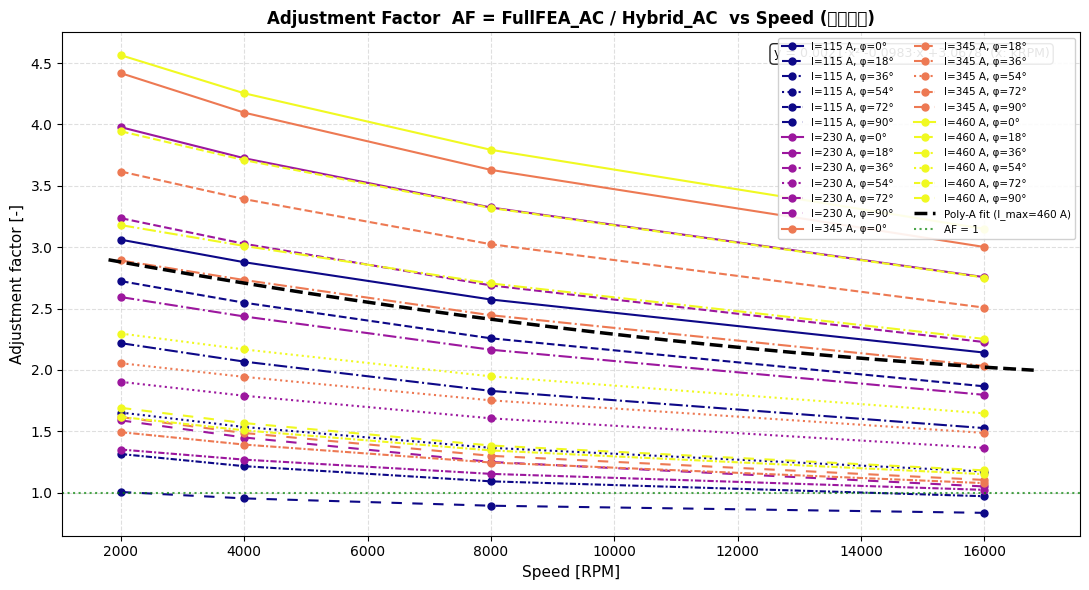

저장: D:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\map_exports\Ref\AF_vs_speed_curves.png


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# [6] 방법 A: AF(speed) 속도만 2차 다항식 + AF vs Speed 시각화
# ─────────────────────────────────────────────────────────────────────────────
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

import numpy as np
import matplotlib.pyplot as plt

# ── 방법 A 피팅: 최대 전류에서 속도만의 2차 다항식 ──────────────────────────
max_curr     = curr_arr.max()
mask_maxcurr = np.isclose(curr_arr, max_curr, rtol=0.01)
spd_mc, af_mc = speeds_k[mask_maxcurr], af_arr[mask_maxcurr]

sort_idx = np.argsort(spd_mc)
spd_mc, af_mc = spd_mc[sort_idx], af_mc[sort_idx]

coeffs_A = np.polyfit(spd_mc, af_mc, deg=2)
af_A_fit = np.polyval(coeffs_A, spd_mc)
a2, a1, a0 = coeffs_A
_coeff_A = coeffs_A.copy()

def af_from_speed_only(speed_rpm):
    return np.polyval(_coeff_A, np.asarray(speed_rpm, float) / 1000.0)

lab_formula_extra = (
    f"(({a2:.6f}*(Speed/1000)^2 + {a1:.6f}*(Speed/1000) + {a0:.6f}) - 1)"
    f" * Stator_Copper_Loss_AC"
)

print("=== 방법 A: 속도만의 2차 다항식 (최대 전류 기준) ===")
print(f"  I_rms = {max_curr:.1f} A 기준")
print(f"  AF(s) = {a2:.6f}\u00b7s\u00b2 + {a1:.6f}\u00b7s + {a0:.6f}   (s: kRPM)\n")
for s, ref, fit in zip(spd_mc, af_mc, af_A_fit):
    print(f"    {s:.0f} kRPM: AF_ref={ref:.3f}, AF_fit={fit:.3f}, \u0394={fit-ref:+.3f}")
print(f"\n  [Motor-CAD Lab \uc218\uc2dd]\n  {lab_formula_extra}")

# ── AF vs Speed 시각화 ──────────────────────────────────────────────────────
unique_currents_s = sorted(set(round(p["current_rms"], 0) for p in af_points))
unique_phases_s   = sorted(set(round(p["phase_deg"],   0) for p in af_points))
unique_speeds_s   = sorted(set(p["speed_rpm"] for p in af_points))

n_curr_s  = len(unique_currents_s)
colors_s  = [plt.cm.plasma(i / max(1, n_curr_s - 1)) for i in range(n_curr_s)]
lstyles_s = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 5))]

fig, ax = plt.subplots(figsize=(11, 6))
ax.set_title("Adjustment Factor  AF = FullFEA_AC / Hybrid_AC  vs Speed (\uc6b4\uc804\uc810\ubcc4)",
             fontsize=12, fontweight='bold')

for ki, curr in enumerate(unique_currents_s):
    for li, ph in enumerate(unique_phases_s):
        pts = sorted(
            [p for p in af_points
             if np.isclose(p["current_rms"], curr, atol=0.6)
             and np.isclose(p["phase_deg"],  ph,   atol=0.6)],
            key=lambda x: x["speed_rpm"]
        )
        if len(pts) < 2:
            continue
        spds = [p["speed_rpm"] for p in pts]
        afs  = [p["AF"]        for p in pts]
        ax.plot(spds, afs,
                marker='o', markersize=5,
                linestyle=lstyles_s[li % len(lstyles_s)],
                color=colors_s[ki], linewidth=1.5,
                label=f"I={curr:.0f} A, \u03c6={ph:.0f}\u00b0")

spd_fit  = np.linspace(min(unique_speeds_s) * 0.9, max(unique_speeds_s) * 1.05, 300)
af_fit_A = af_from_speed_only(spd_fit)
eq_str = f"y = {a2:.4f}\u00b7x\u00b2 {a1:+.4f}\u00b7x {a0:+.4f}  (x: kRPM)"
ax.plot(spd_fit, af_fit_A, 'k--', linewidth=2.5,
        label=f"Poly-A fit (I_max={max_curr:.0f} A)")
ax.text(0.97, 0.97, eq_str, transform=ax.transAxes, fontsize=9,
        va='top', ha='right', bbox=dict(boxstyle='round', fc='white', alpha=0.85))

ax.axhline(y=1.0, color='green', linestyle=':', linewidth=1.5, alpha=0.7, label="AF = 1")
ax.set_xlabel("Speed [RPM]", fontsize=11)
ax.set_ylabel("Adjustment factor [-]", fontsize=11)
ax.legend(fontsize=7.5, loc='upper right', ncol=2, framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(out_dir / "AF_vs_speed_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"저장: {out_dir / 'AF_vs_speed_curves.png'}")


# [6.5] 방법 B 시각화: id-iq 평면 AF 분포 (분리형 RBF)

속도별 id-iq 평면에서의 AF 예측 거동 및 분리형 RBF 곡면을 시각화합니다.


C:\Users\user\AppData\Local\Temp\ipykernel_16540\2695814799.py:52: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16540\2695814799.py:52: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16540\2695814799.py:53: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.savefig(out_dir / "AF_map_visualization.png", dpi=150, bbox_inches='tight')
C:\Users\user\AppData\Local\Temp\ipykernel_16540\2695814799.py:53: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  plt.savefig(out_dir / "AF_map_visualization.png", dpi=150, bbox_inches='tight')


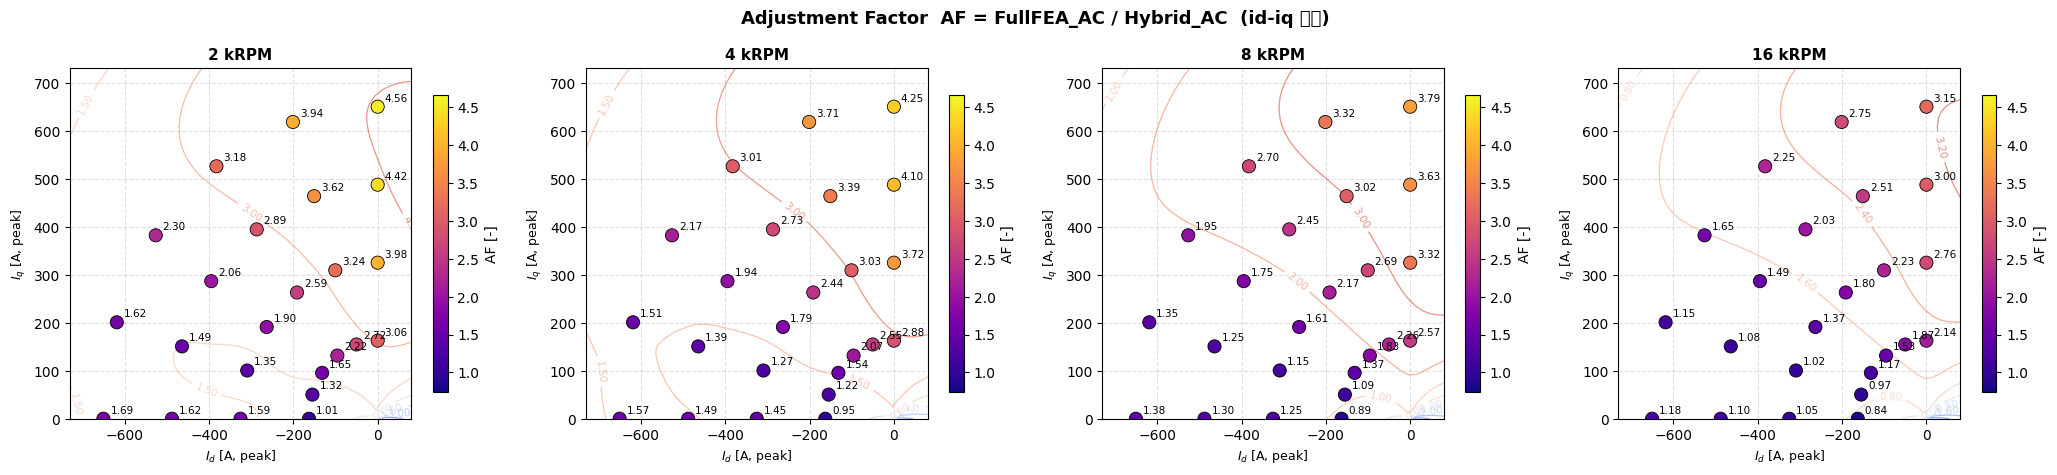

저장: D:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\map_exports\Ref\AF_map_visualization.png


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# [6.5] 방법 B 시각화: id-iq 평면 AF 맵 (속도별)
# ─────────────────────────────────────────────────────────────────────────────
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

import numpy as np
import matplotlib.pyplot as plt

unique_speeds_v = sorted(set(p["speed_rpm"] for p in af_points))
n_spd_v = len(unique_speeds_v)

fig, axes = plt.subplots(1, n_spd_v, figsize=(5.2 * n_spd_v, 4.8))
if n_spd_v == 1:
    axes = [axes]
fig.suptitle("Adjustment Factor  AF = FullFEA_AC / Hybrid_AC  (id-iq plane)",
             fontsize=13, fontweight='bold')

af_vals_all = np.array([p["AF"] for p in af_points])
vmin_af = max(0.5, af_vals_all.min() - 0.1)
vmax_af = af_vals_all.max() + 0.1

for ax, spd in zip(axes, unique_speeds_v):
    pts  = [p for p in af_points if p["speed_rpm"] == spd]
    id_v = np.array([p["id_A"] for p in pts])
    iq_v = np.array([p["iq_A"] for p in pts])
    af_v = np.array([p["AF"]   for p in pts])

    sc = ax.scatter(id_v, iq_v, c=af_v, cmap='plasma', s=90,
                    edgecolors='k', linewidths=0.6,
                    vmin=vmin_af, vmax=vmax_af, zorder=3)
    for x, y, a in zip(id_v, iq_v, af_v):
        ax.annotate(f"{a:.2f}", (x, y), textcoords="offset points",
                    xytext=(5, 4), fontsize=7.5, color='black')

    pad = 80
    id_g = np.linspace(id_v.min() - pad, id_v.max() + pad, 50)
    iq_g = np.linspace(max(0, iq_v.min() - pad), iq_v.max() + pad, 50)
    ID, IQ = np.meshgrid(id_g, iq_g)
    AF_fit = af_from_poly3d(spd, ID.ravel(), IQ.ravel()).reshape(ID.shape)
    ct = ax.contour(ID, IQ, AF_fit, levels=8, cmap='coolwarm', alpha=0.65, linewidths=0.9)
    ax.clabel(ct, fmt="%.2f", fontsize=7.5)

    plt.colorbar(sc, ax=ax, label="AF [-]", shrink=0.85)
    ax.set_xlabel("$I_d$ [A, peak]", fontsize=9)
    ax.set_ylabel("$I_q$ [A, peak]", fontsize=9)
    ax.set_title(f"{spd/1000:.0f} kRPM", fontsize=11, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(out_dir / "AF_map_visualization.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"저장: {out_dir / 'AF_map_visualization.png'}")


# [6.6] 방법 B 3D 표면 시각화: AF(id, iq) 곡면 (속도별)

C:\Users\user\AppData\Local\Temp\ipykernel_16540\161974322.py:45: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16540\161974322.py:45: UserWarning: Glyph 48277 (\N{HANGUL SYLLABLE BEOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16540\161974322.py:45: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16540\161974322.py:45: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16540\161974322.py:45: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16540\161974322.py:45: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s)

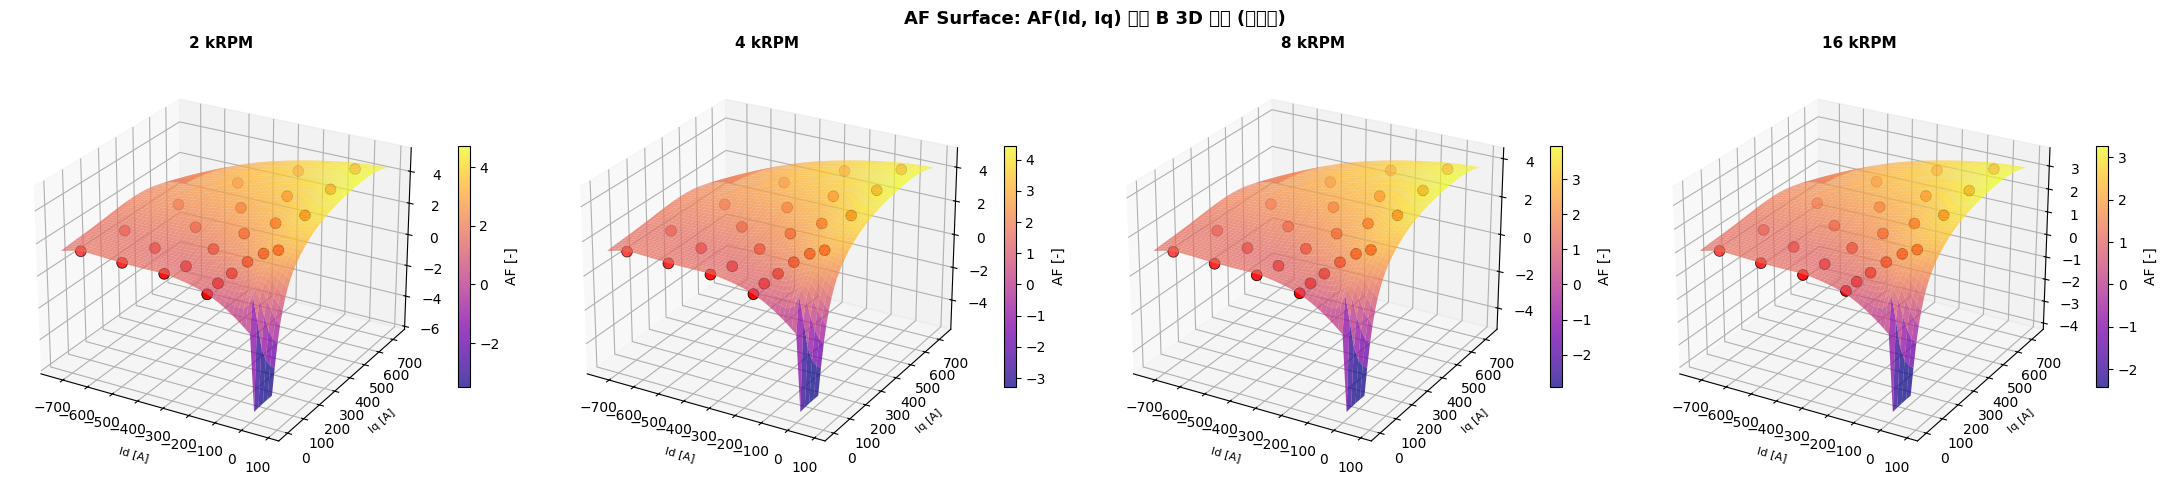

저장: D:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\map_exports\Ref\AF_3D_surface.png


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# [6.6] 방법 B 3D 표면 시각화: AF(id, iq) 곡면 (속도별)
# ─────────────────────────────────────────────────────────────────────────────
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

unique_speeds_v = sorted(set(p["speed_rpm"] for p in af_points))
n_spd_v = len(unique_speeds_v)

fig = plt.figure(figsize=(5.5 * n_spd_v, 5.0))
fig.suptitle("AF Surface: AF(Id, Iq) — Method B 3D Surface (per speed)", fontsize=13, fontweight="bold")

for k, spd in enumerate(unique_speeds_v):
    ax = fig.add_subplot(1, n_spd_v, k + 1, projection="3d")

    pts  = [p for p in af_points if p["speed_rpm"] == spd]
    id_v = np.array([p["id_A"] for p in pts])
    iq_v = np.array([p["iq_A"] for p in pts])
    af_v = np.array([p["AF"]   for p in pts])

    pad = 80
    id_g = np.linspace(id_v.min() - pad, id_v.max() + pad, 50)
    iq_g = np.linspace(max(0, iq_v.min() - pad), iq_v.max() + pad, 50)
    ID, IQ = np.meshgrid(id_g, iq_g)
    AF_fit = af_from_poly3d(spd, ID, IQ)

    surf = ax.plot_surface(ID, IQ, AF_fit, cmap="plasma", alpha=0.75,
                           linewidth=0, antialiased=True)
    ax.scatter(id_v, iq_v, af_v, c="red", s=60,
               edgecolors="k", linewidths=0.6, zorder=5, label="FEA data")

    fig.colorbar(surf, ax=ax, shrink=0.55, label="AF [-]")
    ax.set_xlabel("Id [A]", fontsize=8)
    ax.set_ylabel("Iq [A]", fontsize=8)
    ax.set_zlabel("AF [-]", fontsize=8)
    ax.set_title(f"{spd/1000:.0f} kRPM", fontsize=11, fontweight="bold")
    ax.view_init(elev=25, azim=-60)

plt.tight_layout()
plt.savefig(out_dir / "AF_3D_surface.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"저장: {out_dir / 'AF_3D_surface.png'}")


# [7] 대리 모델 성능 비교 및 시각화

- 3D TPS RBF 모델과 1D x 2D Separable RBF 모델의 예측 오차(Train MAE 및 Leave-One-Out CV 오차)를 직접 비교합니다.
- 두 모델의 예측 데이터 Parity Plot 및 3-way Boxplot을 생성하여 비교 시각화하고 최종 JSON 데이터를 내보냅니다.


=== RBF 보정 오차 검증 및 비교: 3D RBF vs Separable vs FullFEA (Ref) ===

  LOOCV 계산 중 (약 1.5초 소요)... 
=== RBF 보정 오차 최종 비교 결과 ===
  1) Hybrid (보정 전):        Train MAE=45.43% | MaxAE=78.09%
  2) 3D TPS RBF:             Train MAE=0.00% | MaxAE=0.00% | LOOCV MAE=2.69%
  3) Separable (분리형 RBF):   Train MAE=1.40% | MaxAE=17.03% | LOOCV MAE=3.16%


C:\Users\user\AppData\Local\Temp\ipykernel_16540\2993710980.py:154: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([ea, e3, es], labels=['Hybrid (보정 전)', '3D RBF', 'Separable RBF'], patch_artist=True, widths=0.4)
C:\Users\user\AppData\Local\Temp\ipykernel_16540\2993710980.py:165: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16540\2993710980.py:165: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16540\2993710980.py:165: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16540\2993710980.py:165: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missi

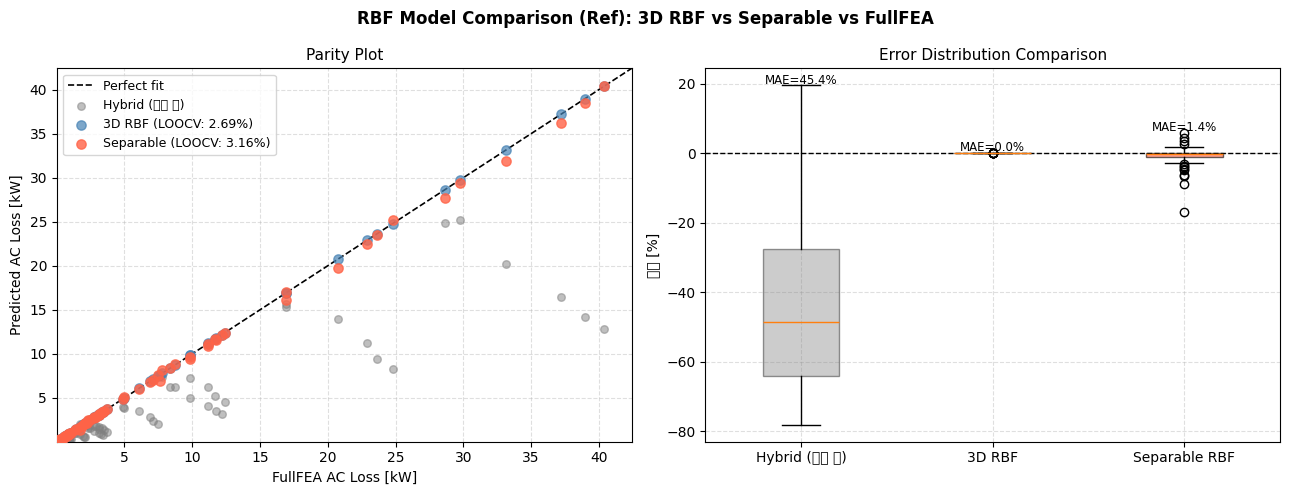

C:\Users\user\AppData\Local\Temp\ipykernel_16540\2993710980.py:357: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16540\2993710980.py:357: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16540\2993710980.py:357: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


그림 저장 완료: D:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\map_exports\Ref\RBF_correction_validation_Ref.png
JSON 모델 저장 완료: D:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\map_exports\Ref\AF_RBF_model_Ref.json

  대화형 4-Way 비교 플롯 로딩...


C:\Users\user\AppData\Local\Temp\ipykernel_16540\2993710980.py:357: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16540\2993710980.py:357: UserWarning: Glyph 52280 (\N{HANGUL SYLLABLE CAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16540\2993710980.py:357: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16540\2993710980.py:357: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16540\2993710980.py:357: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16540\2993710980.py:357: UserWarning: Glyph 47215 (\N{HANGUL SYLLABLE ROS}) missing fro

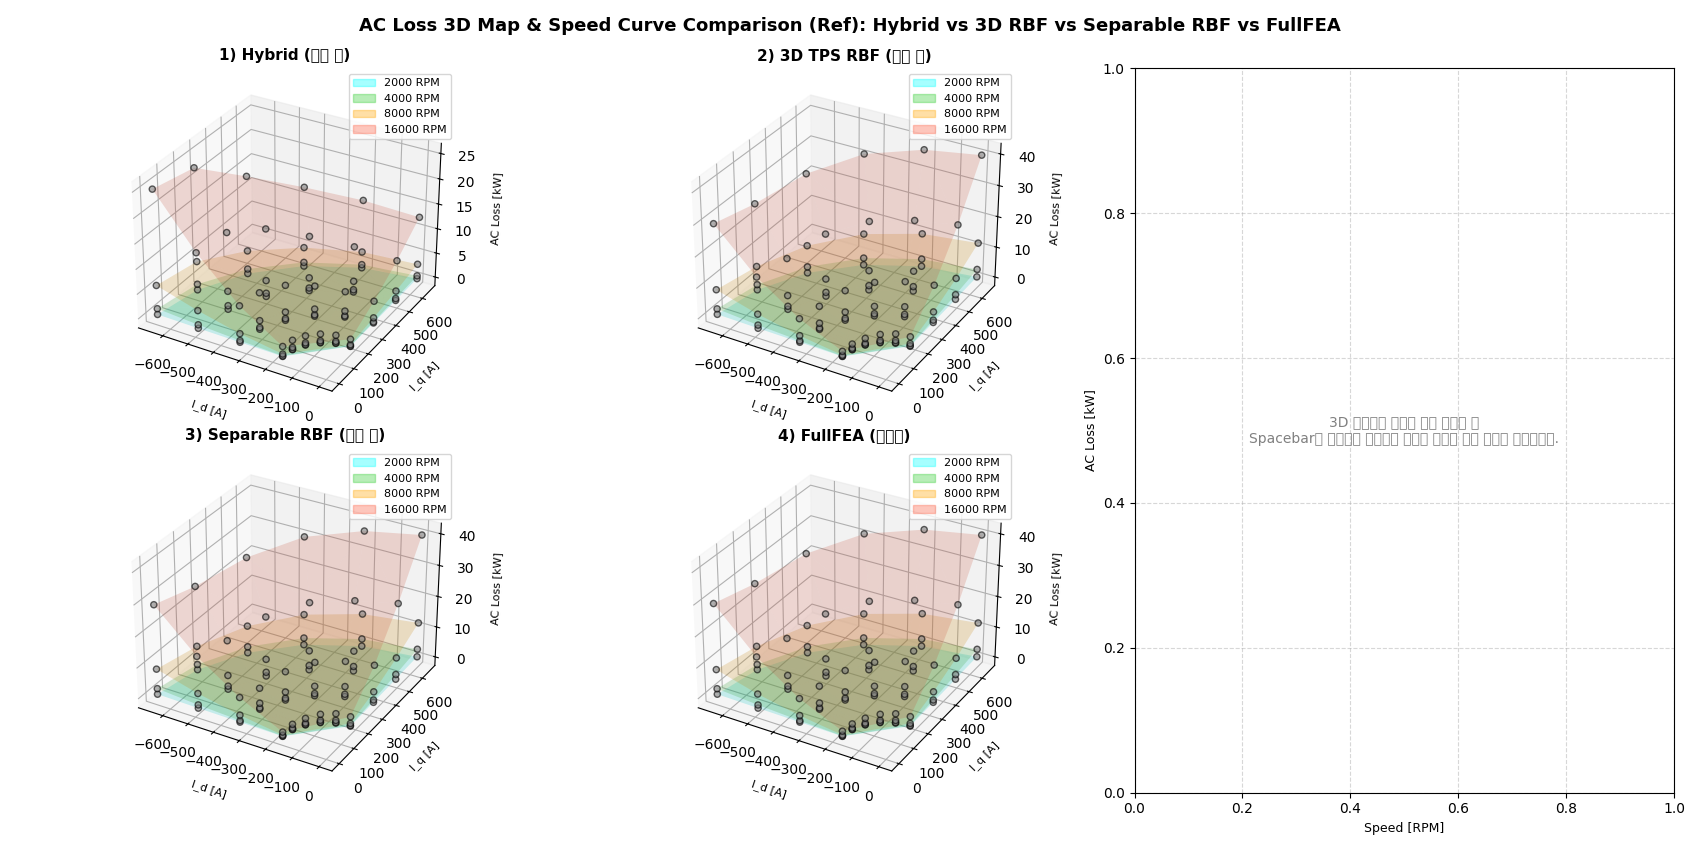

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# [7] RBF 모델 비교 검증: 3D TPS RBF vs. 1D x 2D Separable RBF vs. FullFEA
# ─────────────────────────────────────────────────────────────────────────────
try:
    get_ipython().run_line_magic('matplotlib', 'interactive')
except Exception:
    pass

import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

print(f"=== RBF 보정 오차 검증 및 비교: 3D RBF vs Separable vs FullFEA ({MODEL_SCALE}) ===\n")

h_ac_arr = np.array([p["hybrid_ac_kW"] for p in af_points])
f_ac_arr = np.array([p["fea_ac_kW"] for p in af_points])

# ── 훈련 세트 오차 계산
err_raw, err_3d, err_sep = [], [], []
rows = []
for p in af_points:
    spd   = p["speed_rpm"]
    irms  = p["current_rms"]
    phase = p["phase_deg"]
    h_ac  = p["hybrid_ac_kW"]
    f_ac  = p["fea_ac_kW"]
    
    af_3d  = float(af_from_rbf_3d(spd, irms, phase))
    af_sep = float(af_from_rbf_separable(spd, irms, phase))
    
    corr_3d  = h_ac * af_3d
    corr_sep = h_ac * af_sep
    
    e_raw = (h_ac - f_ac) / (f_ac + 1e-12) * 100
    e_3d  = (corr_3d - f_ac) / (f_ac + 1e-12) * 100
    e_sep = (corr_sep - f_ac) / (f_ac + 1e-12) * 100
    
    err_raw.append(e_raw)
    err_3d.append(e_3d)
    err_sep.append(e_sep)
    rows.append((spd, irms, phase, h_ac, f_ac, corr_3d, corr_sep, e_raw, e_3d, e_sep))

ea = np.array(err_raw)
e3 = np.array(err_3d)
es = np.array(err_sep)

# ── LOOCV 계산
print("  LOOCV 계산 중 (약 1.5초 소요)... ")
loocv_errors_3d = []
for i in range(n):
    X_tr = np.delete(X_data, i, axis=0)
    y_tr = np.delete(af_arr, i, axis=0)
    Phi_tr = np.zeros((n-1, n-1))
    for j in range(n-1):
        Phi_tr[:, j] = _rbf_k_3d(X_tr[:, 0], X_tr[:, 1], X_tr[:, 2],
                                 X_tr[j, 0], X_tr[j, 1], X_tr[j, 2])
    w_tr = np.linalg.solve(Phi_tr + LAM * np.eye(n-1), y_tr)
    
    r2 = (X_data[i, 0] - X_tr[:, 0])**2 / LS_S**2        + (X_data[i, 1] - X_tr[:, 1])**2 / LS_I**2        + (X_data[i, 2] - X_tr[:, 2])**2 / LS_P**2
    r = np.sqrt(r2)
    K = r2 * np.log(r + 1e-12)
    y_pred = K @ w_tr
    corr_val = h_ac_arr[i] * y_pred
    loocv_errors_3d.append(abs((corr_val - f_ac_arr[i]) / f_ac_arr[i] * 100))
mae_loocv_3d = np.mean(loocv_errors_3d)

loocv_errors_sep = []
for i in range(n):
    base_train_idx = [idx for idx in base_idx if idx != i]
    X_base_tr = X_data[base_train_idx, 1:3]
    y_base_tr = af_arr[base_train_idx]
    
    Phi_g_tr = np.zeros((len(base_train_idx), len(base_train_idx)))
    for j in range(len(base_train_idx)):
        Phi_g_tr[:, j] = _rbf_2d_k(X_base_tr[:, 0], X_base_tr[:, 1],
                                    X_base_tr[j, 0], X_base_tr[j, 1])
    w_g_tr = np.linalg.solve(Phi_g_tr + LAM * np.eye(len(base_train_idx)), y_base_tr)
    
    def predict_g_tr(I, theta):
        I = np.asarray(I, float)
        theta = np.asarray(theta, float)
        I, theta = np.broadcast_arrays(I, theta)
        orig = I.shape

        Iv, thv = I.ravel()[:, None], theta.ravel()[:, None]
        r2 = (Iv - X_base_tr[:, 0])**2 / LS_I**2 + (thv - X_base_tr[:, 1])**2 / LS_P**2
        r = np.sqrt(r2)
        K = r2 * np.log(r + 1e-12)
        result = K @ w_g_tr
        return result.reshape(orig) if orig else float(result[0])
        
    cal_train_idx = [idx for idx in selected_other_idx if idx != i]
    f_vals_tr = []
    for idx in cal_train_idx:
        spd = speeds_k[idx]
        I_val = irms_arr[idx]
        th_val = phase_arr[idx]
        af_actual = af_arr[idx]
        g_val = predict_g_tr(I_val, th_val)
        f_val = af_actual / (g_val + 1e-12)
        f_vals_tr.append((spd, f_val))
        
    f_by_speed_tr = {2.0: [1.0]}
    for spd, f_val in f_vals_tr:
        if spd not in f_by_speed_tr:
            f_by_speed_tr[spd] = []
        f_by_speed_tr[spd].append(f_val)
        
    speed_coords_tr = []
    f_coords_tr = []
    for spd in sorted(f_by_speed_tr.keys()):
        speed_coords_tr.append(spd)
        f_coords_tr.append(np.mean(f_by_speed_tr[spd]))
        
    p_coeffs_tr = np.polyfit(speed_coords_tr, f_coords_tr, 2)
    p_func_tr = np.poly1d(p_coeffs_tr)
    
    g_val_i = predict_g_tr(X_data[i, 1], X_data[i, 2])
    f_val_i = p_func_tr(X_data[i, 0])
    y_pred_i = f_val_i * g_val_i
    corr_val = h_ac_arr[i] * y_pred_i
    loocv_errors_sep.append(abs((corr_val - f_ac_arr[i]) / f_ac_arr[i] * 100))
mae_loocv_sep = np.mean(loocv_errors_sep)

print("=== RBF 보정 오차 최종 비교 결과 ===")
print(f"  1) Hybrid (보정 전):        Train MAE={np.abs(ea).mean():.2f}% | MaxAE={np.abs(ea).max():.2f}%")
print(f"  2) 3D TPS RBF:             Train MAE={np.abs(e3).mean():.2f}% | MaxAE={np.abs(e3).max():.2f}% | LOOCV MAE={mae_loocv_3d:.2f}%")
print(f"  3) Separable (분리형 RBF):   Train MAE={np.abs(es).mean():.2f}% | MaxAE={np.abs(es).max():.2f}% | LOOCV MAE={mae_loocv_sep:.2f}%")

# ── 시각화 및 그림 저장
fea_all   = np.array([r[4] for r in rows])
hybr_all  = np.array([r[3] for r in rows])
corr_3d   = np.array([r[5] for r in rows])
corr_sep  = np.array([r[6] for r in rows])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"RBF Model Comparison ({MODEL_SCALE}): 3D RBF vs Separable vs FullFEA", fontsize=12, fontweight='bold')

ax = axes[0]
lim = [min(fea_all.min(), hybr_all.min(), corr_3d.min(), corr_sep.min()) * 0.9,
       max(fea_all.max(), hybr_all.max(), corr_3d.max(), corr_sep.max()) * 1.05]
ax.plot(lim, lim, 'k--', linewidth=1.2, label='Perfect fit')
ax.scatter(fea_all, hybr_all, c='grey',      s=30, alpha=0.5, label='Hybrid (uncorrected)', zorder=2)
ax.scatter(fea_all, corr_3d,  c='steelblue', s=45, alpha=0.7, label=f'3D RBF (LOOCV: {mae_loocv_3d:.2f}%)', zorder=3)
ax.scatter(fea_all, corr_sep, c='tomato',    s=45, alpha=0.8, label=f'Separable (LOOCV: {mae_loocv_sep:.2f}%)', zorder=4)
ax.set_xlabel("FullFEA AC Loss [kW]", fontsize=10)
ax.set_ylabel("Predicted AC Loss [kW]", fontsize=10)
ax.set_title("Parity Plot", fontsize=11)
ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlim(lim); ax.set_ylim(lim)

ax2 = axes[1]
bp = ax2.boxplot([ea, e3, es], labels=['Hybrid (uncorr.)', '3D RBF', 'Separable RBF'], patch_artist=True, widths=0.4)
bp['boxes'][0].set_facecolor('grey');       bp['boxes'][0].set_alpha(0.4)
bp['boxes'][1].set_facecolor('steelblue');  bp['boxes'][1].set_alpha(0.6)
bp['boxes'][2].set_facecolor('tomato');     bp['boxes'][2].set_alpha(0.6)
ax2.axhline(0, color='k', linestyle='--', linewidth=1)
ax2.set_ylabel("Error [%]", fontsize=10)
ax2.set_title("Error Distribution Comparison", fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.4)
for i, (arr, x) in enumerate([(ea, 1), (e3, 2), (es, 3)]):
    ax2.text(x, arr.max() + 0.5, f"MAE={np.abs(arr).mean():.1f}%", ha='center', fontsize=8.5, color='black')

plt.tight_layout()
val_plot_path = out_dir / f"RBF_correction_validation_{MODEL_SCALE}.png"
plt.savefig(val_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"그림 저장 완료: {val_plot_path}")

# ── 모델 내보내기
export = {
    "model_type": f"RBF_{MODEL_SCALE}",
    "3D_model": {
        "model": "3D_TPS_RBF",
        "n_centers": int(n),
        "weights": rbf_weights_3d.tolist(),
        "validation": {
            "Train_MAE_pct": float(np.abs(e3).mean()),
            "LOOCV_MAE_pct": float(mae_loocv_3d),
        },
        "mcad_formula": rbf_formula_3d
    },
    "separable_model": {
        "model": "Separable_1D_2D_RBF",
        "n_base_centers": int(n_base),
        "base_weights": w_g.tolist(),
        "speed_poly_coeffs": p_coeffs.tolist(),
        "validation": {
            "Train_MAE_pct": float(np.abs(es).mean()),
            "LOOCV_MAE_pct": float(mae_loocv_sep),
        },
        "mcad_formula": rbf_formula_separable
    },
    "mcad_formula_full": rbf_formula_3d,
    "mcad_formula_reduced_30": rbf_formula_separable,
    "mcad_formula_top20": rbf_formula_separable,
    "length_scales": {"LS_S_kRPM": float(LS_S), "LS_I_A": float(LS_I), "LS_P_deg": float(LS_P)},
    "af_points": af_points
}
with open(rbf_model_path, "w", encoding="utf-8") as f:
    json.dump(export, f, ensure_ascii=False, indent=2)
print(f"JSON 모델 저장 완료: {rbf_model_path}")

# ── [대화형 4-Way 비교 플롯 구현] ───────────────────────────────────────────
try:
    import IPython
    shell = IPython.get_ipython()
    if shell is not None:
        import os, sys
        has_vscode_env = any(k.startswith('VSCODE_') for k in os.environ.keys())
        has_vscode_modules = any('vscode' in m.lower() for m in sys.modules.keys())
        selected_backend = 'widget' if (has_vscode_env and has_vscode_modules) else 'inline'
        if selected_backend == 'widget':
            shell.run_line_magic('matplotlib', 'widget')
        else:
            shell.run_line_magic('matplotlib', 'inline')
except Exception:
    pass

import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D

print("\n  대화형 4-Way 비교 플롯 로딩...")
speeds = np.array([p["speed_rpm"] for p in af_points])
irms = np.array([p["current_rms"] for p in af_points])
phases = np.array([p["phase_deg"] for p in af_points])
id_vals = np.array([p["id_A"] for p in af_points])
iq_vals = np.array([p["iq_A"] for p in af_points])

loss_hyb = np.array([p["hybrid_ac_kW"] for p in af_points])
loss_fea = np.array([p["fea_ac_kW"] for p in af_points])
loss_3d  = np.array([float(af_from_rbf_3d(p["speed_rpm"], p["current_rms"], p["phase_deg"])) * p["hybrid_ac_kW"] for p in af_points])
loss_sep = np.array([float(af_from_rbf_separable(p["speed_rpm"], p["current_rms"], p["phase_deg"])) * p["hybrid_ac_kW"] for p in af_points])

fig_int = plt.figure(figsize=(17, 8.5))
fig_int.suptitle(f"AC Loss 3D Map & Speed Curve Comparison ({MODEL_SCALE}): Hybrid vs 3D RBF vs Separable RBF vs FullFEA", fontsize=13, fontweight='bold')

ax_hyb = fig_int.add_subplot(2, 3, 1, projection='3d')
ax_3d  = fig_int.add_subplot(2, 3, 2, projection='3d')
ax_sep = fig_int.add_subplot(2, 3, 4, projection='3d')
ax_fea = fig_int.add_subplot(2, 3, 5, projection='3d')
ax_curve = fig_int.add_subplot(2, 3, (3, 6))

ax_hyb.set_title("1) Hybrid (uncorrected)", fontsize=11, fontweight='bold')
ax_3d.set_title("2) 3D TPS RBF (corrected)", fontsize=11, fontweight='bold')
ax_sep.set_title("3) Separable RBF (corrected)", fontsize=11, fontweight='bold')
ax_fea.set_title("4) FullFEA (reference)", fontsize=11, fontweight='bold')

unique_speeds = sorted(list(set(speeds)))
speed_colors = {2000: 'cyan', 4000: 'limegreen', 8000: 'orange', 16000: 'tomato'}
default_colors = ['cyan', 'limegreen', 'orange', 'tomato']
axes_3d = [ax_hyb, ax_3d, ax_sep, ax_fea]
losses_list = [loss_hyb, loss_3d, loss_sep, loss_fea]

legend_patches = []
for i, spd in enumerate(unique_speeds):
    color = speed_colors.get(spd, default_colors[i % len(default_colors)])
    legend_patches.append(mpatches.Patch(color=color, alpha=0.35, label=f"{spd} RPM"))
    idx_spd = (speeds == spd)
    if np.any(idx_spd) and np.sum(idx_spd) >= 3:
        for ax, loss_val in zip(axes_3d, losses_list):
            ax.plot_trisurf(id_vals[idx_spd], iq_vals[idx_spd], loss_val[idx_spd], color=color, edgecolor='none', alpha=0.2)

sc_hyb = ax_hyb.scatter(id_vals, iq_vals, loss_hyb, c='grey', s=20, picker=True, pickradius=5, edgecolors='black', alpha=0.6)
sc_3d  = ax_3d.scatter(id_vals, iq_vals, loss_3d,   c='grey', s=20, picker=True, pickradius=5, edgecolors='black', alpha=0.6)
sc_sep = ax_sep.scatter(id_vals, iq_vals, loss_sep, c='grey', s=20, picker=True, pickradius=5, edgecolors='black', alpha=0.6)
sc_fea = ax_fea.scatter(id_vals, iq_vals, loss_fea, c='grey', s=20, picker=True, pickradius=5, edgecolors='black', alpha=0.6)
scatters = [sc_hyb, sc_3d, sc_sep, sc_fea]

for ax in axes_3d:
    ax.set_xlabel("I_d [A]", fontsize=8, labelpad=5)
    ax.set_ylabel("I_q [A]", fontsize=8, labelpad=5)
    ax.set_zlabel("AC Loss [kW]", fontsize=8, labelpad=5)
    ax.legend(handles=legend_patches, fontsize=8)

ax_curve.text(0.5, 0.5, "Click any point in the 3D plot,
press Spacebar or click to show speed curves on the right.", 
             ha="center", va="center", fontsize=10, color="gray")
ax_curve.set_xlabel("Speed [RPM]", fontsize=9)
ax_curve.set_ylabel("AC Loss [kW]", fontsize=9)
ax_curve.grid(True, linestyle="--", alpha=0.5)

selected_pt = {"current_rms": None, "phase_deg": None, "id_A": None, "iq_A": None}
highlights = []
annots = []
for ax in axes_3d:
    annot = ax.text2D(0.02, 0.95, "", transform=ax.transAxes, bbox=dict(boxstyle="round", fc="w", alpha=0.8), fontsize=8)
    annot.set_visible(False)
    annots.append(annot)

def update_2d_curve(curr, ph):
    ax_curve.clear()
    match_pts = [p for p in af_points if np.isclose(p["current_rms"], curr) and np.isclose(p["phase_deg"], ph)]
    match_pts = sorted(match_pts, key=lambda x: x["speed_rpm"])
    
    curve_speeds = [p["speed_rpm"] for p in match_pts]
    c_loss_hyb = [p["hybrid_ac_kW"] for p in match_pts]
    c_loss_fea = [p["fea_ac_kW"] for p in match_pts]
    c_loss_3d  = [float(af_from_rbf_3d(p["speed_rpm"], p["current_rms"], p["phase_deg"])) * p["hybrid_ac_kW"] for p in match_pts]
    c_loss_sep = [float(af_from_rbf_separable(p["speed_rpm"], p["current_rms"], p["phase_deg"])) * p["hybrid_ac_kW"] for p in match_pts]
    
    ax_curve.plot(curve_speeds, c_loss_hyb, marker='o', linestyle='-',  color='grey',      linewidth=1.5, label="1) Hybrid (uncorrected)")
    ax_curve.plot(curve_speeds, c_loss_3d,  marker='s', linestyle='-',  color='steelblue', linewidth=2,   label="2) 3D RBF (corrected)")
    ax_curve.plot(curve_speeds, c_loss_sep, marker='^', linestyle='-',  color='tomato',    linewidth=2,   label="3) Separable (corrected)")
    ax_curve.plot(curve_speeds, c_loss_fea, marker='*', linestyle='--', color='black',     linewidth=2,   label="4) FullFEA Reference")
    
    for xs, yh, y3, ys, yf in zip(curve_speeds, c_loss_hyb, c_loss_3d, c_loss_sep, c_loss_fea):
        ax_curve.annotate(f"{yh:.2f}", xy=(xs, yh), xytext=(4, 8),   textcoords="offset points", fontsize=8, color="grey")
        ax_curve.annotate(f"{y3:.2f}", xy=(xs, y3), xytext=(4, 0),   textcoords="offset points", fontsize=8, color="steelblue")
        ax_curve.annotate(f"{ys:.2f}", xy=(xs, ys), xytext=(4, -8),  textcoords="offset points", fontsize=8, color="tomato")
        ax_curve.annotate(f"{yf:.2f}", xy=(xs, yf), xytext=(4, -16), textcoords="offset points", fontsize=8, color="black")
        
    ax_curve.set_title(f"AC Loss vs Speed Comparison\n(I_rms={curr:.1f}A, Phase={ph:.1f}°)", fontsize=11, fontweight='bold')
    ax_curve.set_xlabel("Speed [RPM]", fontsize=9)
    ax_curve.set_ylabel("AC Loss [kW]", fontsize=9)
    ax_curve.grid(True, linestyle="--", alpha=0.5)
    ax_curve.legend(fontsize=9, loc="upper left")

def on_pick(event):
    if event.artist not in scatters:
        return
    idx = event.ind[0]
    p_sel = af_points[idx]
    curr = p_sel["current_rms"]
    ph = p_sel["phase_deg"]
    
    selected_pt["current_rms"] = curr
    selected_pt["phase_deg"] = ph
    selected_pt["id_A"] = p_sel["id_A"]
    selected_pt["iq_A"] = p_sel["iq_A"]
    
    for h in highlights:
        h.remove()
    highlights.clear()
    
    same_pt_idx = np.where((irms == curr) & (phases == ph))[0]
    for ax, loss_val in zip(axes_3d, losses_list):
        h = ax.scatter(id_vals[same_pt_idx], iq_vals[same_pt_idx], loss_val[same_pt_idx], color='red', s=60, edgecolors='black', linewidths=1.5, zorder=10)
        highlights.append(h)
        
    msg = f"Selected: I_rms={curr:.1f}A, Phase={ph:.1f}°\nId={selected_pt['id_A']:.1f}A, Iq={selected_pt['iq_A']:.1f}A"
    for annot in annots:
        annot.set_text(msg)
        annot.set_visible(True)
        
    update_2d_curve(curr, ph)
    fig_int.canvas.draw_idle()

def on_key(event):
    if event.key != ' ' or selected_pt["current_rms"] is None:
        return
    update_2d_curve(selected_pt["current_rms"], selected_pt["phase_deg"])
    fig_int.canvas.draw_idle()

fig_int.canvas.mpl_connect('pick_event', on_pick)
fig_int.canvas.mpl_connect('key_press_event', on_key)
plt.tight_layout()
plt.show()


# [8] Ablation Study: RBF Performance vs. Number of Training Points

Sweeps the number of FullFEA data points used to build each model and measures prediction error.

- **3D TPS RBF**: subsample n_centers from 106 total (stratified by speed) → Train MAE / Held-out MAE (mean ± std over 10 seeds)
- **Separable RBF**: grid search over n_base (2kRPM base pts) × n_speed/spd (calibration pts per non-base speed) → Full MAE heatmap

Total points: 96  /  Per speed: {'2000RPM': 24, '4000RPM': 24, '8000RPM': 24, '16000RPM': 24}

=== 3D TPS RBF Ablation  (n_centers = [4, 8, 12, 16, 20, 24, 28, 32, 40, 50, 60, 80, 96]) ===
  n=  4: Train=0.00+/-0.00%  Held-out=686.68+/-1131.57%
  n=  8: Train=0.00+/-0.01%  Held-out=20346.87+/-60476.80%
  n= 12: Train=0.00+/-0.00%  Held-out=348.52+/-928.41%
  n= 16: Train=0.00+/-0.00%  Held-out=25.41+/-22.74%
  n= 20: Train=0.00+/-0.00%  Held-out=15.86+/-7.79%
  n= 24: Train=0.00+/-0.00%  Held-out=12.11+/-5.49%
  n= 28: Train=0.00+/-0.00%  Held-out=9.99+/-3.65%
  n= 32: Train=0.00+/-0.00%  Held-out=8.53+/-4.00%
  n= 40: Train=0.00+/-0.00%  Held-out=6.03+/-1.23%
  n= 50: Train=0.00+/-0.00%  Held-out=5.35+/-1.30%
  n= 60: Train=0.00+/-0.00%  Held-out=4.09+/-1.89%
  n= 80: Train=0.00+/-0.00%  Held-out=2.74+/-1.31%
  n= 96: Train=0.00+/-0.00%  Held-out=nan+/-nan%

=== Separable RBF Ablation  n_base=[4, 6, 8, 10, 12, 16, 20, 24, 30] x n_spd/spd=[1, 2, 3, 4, 6, 8] ===
  n_base= 4: ns=1->556.7

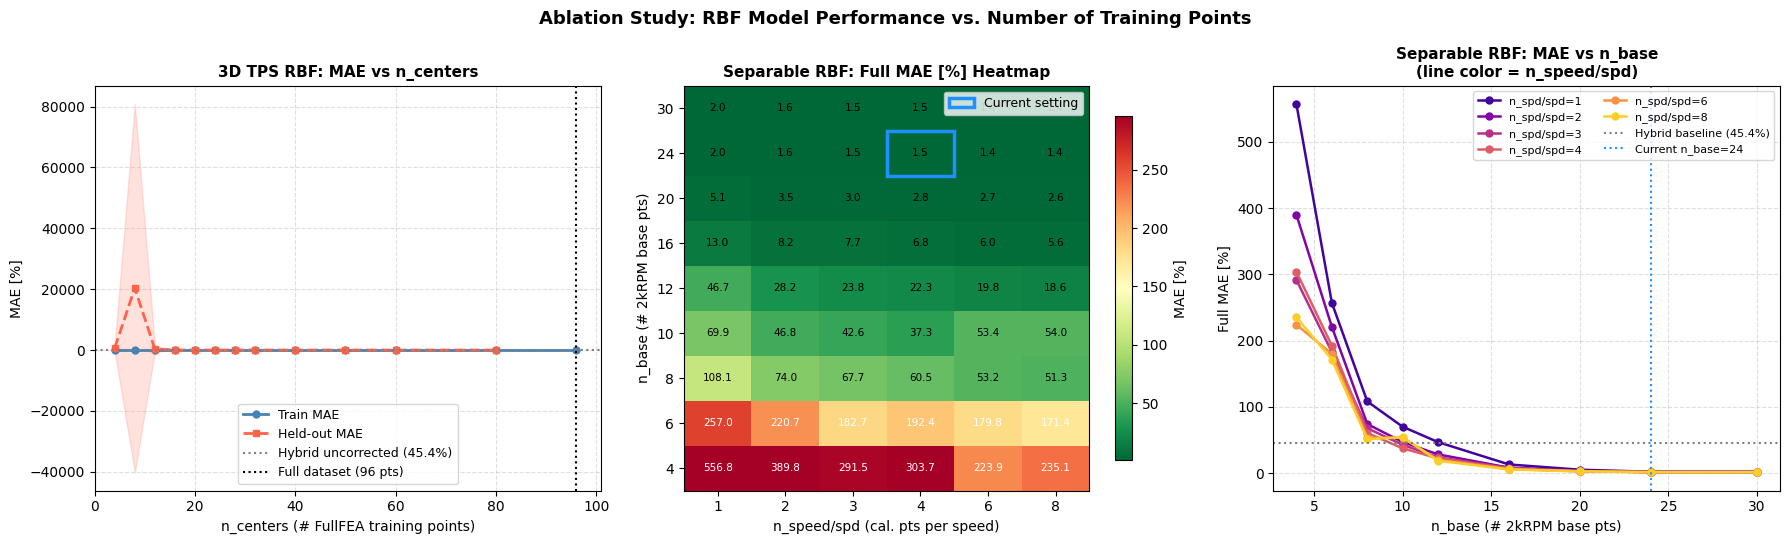

Saved: D:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\map_exports\Ref\ablation_study_Ref.png

=== Summary: 3D RBF Held-out MAE vs n_centers ===
  n=  4: 686.68 +/- 1131.57%
  n=  8: 20346.87 +/- 60476.80%
  n= 12: 348.52 +/- 928.41%
  n= 16: 25.41 +/- 22.74%
  n= 20: 15.86 +/- 7.79%
  n= 24: 12.11 +/- 5.49%
  n= 28: 9.99 +/- 3.65%
  n= 32: 8.53 +/- 4.00%
  n= 40: 6.03 +/- 1.23%
  n= 50: 5.35 +/- 1.30%
  n= 60: 4.09 +/- 1.89%
  n= 80: 2.74 +/- 1.31%
  n= 96: nan +/- nan% <- current (full)

=== Summary: Separable RBF ===
  Best:    n_base=24, n_spd=8 -> MAE=1.37%
  Current: n_base=24, n_spd=4 -> MAE=1.47%


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# [8] Ablation Study: RBF Performance vs. Number of Data Points
# ─────────────────────────────────────────────────────────────────────────────
try:
    get_ipython().run_line_magic('matplotlib', 'interactive')
except Exception:
    pass
import numpy as np
import matplotlib.pyplot as plt

N_TOTAL = len(af_points)
N_SEEDS = 10

# ── Speed-grouped indices ─────────────────────────────────────────────────────
unique_spds_abl = sorted(set(speeds_k))
spd_groups_abl  = {s: np.where(np.abs(speeds_k - s) < 0.01)[0] for s in unique_spds_abl}
n_per_spd_print = {f"{int(s*1000)}RPM": len(v) for s, v in spd_groups_abl.items()}
print(f"Total points: {N_TOTAL}  /  Per speed: {n_per_spd_print}")

other_spds_abl = [s for s in unique_spds_abl if s != 2.0]

# ── Stratified sampling ───────────────────────────────────────────────────────
def _stratified_idx(n_centers, seed):
    rng    = np.random.RandomState(seed)
    n_spd  = len(unique_spds_abl)
    base_n = n_centers // n_spd
    rem    = n_centers % n_spd
    result = []
    for k, s in enumerate(unique_spds_abl):
        grp = spd_groups_abl[s]
        n_d = min(base_n + (1 if k < rem else 0), len(grp))
        result.extend(rng.choice(grp, n_d, replace=False).tolist())
    return np.sort(result)

# ── 3D TPS RBF fit/evaluate ───────────────────────────────────────────────────
def _fit_eval_3d(train_idx):
    nc = len(train_idx)
    sk = speeds_k[train_idx];  ik = irms_arr[train_idx];  pk = phase_arr[train_idx]
    yk = af_arr[train_idx]
    Phi = np.zeros((nc, nc))
    for j in range(nc):
        r2 = (sk-sk[j])**2/LS_S**2 + (ik-ik[j])**2/LS_I**2 + (pk-pk[j])**2/LS_P**2
        Phi[:, j] = r2 * np.log(np.sqrt(r2) + 1e-12)
    try:
        w = np.linalg.solve(Phi + LAM * np.eye(nc), yk)
    except np.linalg.LinAlgError:
        return None, None
    r2_all = (speeds_k[:,None]-sk)**2/LS_S**2 + (irms_arr[:,None]-ik)**2/LS_I**2 + (phase_arr[:,None]-pk)**2/LS_P**2
    K_all  = r2_all * np.log(np.sqrt(r2_all) + 1e-12)
    af_pred  = K_all @ w
    err_pct  = np.abs((h_ac_arr * af_pred - f_ac_arr) / (f_ac_arr + 1e-12) * 100)
    test_idx = np.setdiff1d(np.arange(N_TOTAL), train_idx)
    tr_mae   = float(err_pct[train_idx].mean())
    te_mae   = float(err_pct[test_idx].mean()) if len(test_idx) > 0 else np.nan
    return tr_mae, te_mae

# ── Separable RBF fit/evaluate ────────────────────────────────────────────────
all_base_idx_abl = spd_groups_abl[2.0]

def _fit_eval_sep(n_base, n_per_spd_cal, seed):
    rng  = np.random.RandomState(seed)
    nb   = min(n_base, len(all_base_idx_abl))
    bsel = rng.choice(all_base_idx_abl, nb, replace=False)
    ib, pb, yb = irms_arr[bsel], phase_arr[bsel], af_arr[bsel]

    Pg = np.zeros((nb, nb))
    for j in range(nb):
        r2 = (ib - ib[j])**2/LS_I**2 + (pb - pb[j])**2/LS_P**2
        Pg[:, j] = r2 * np.log(np.sqrt(r2) + 1e-12)
    try:
        wg = np.linalg.solve(Pg + LAM * np.eye(nb), yb)
    except np.linalg.LinAlgError:
        return None

    def _g(I, th):
        I, th = np.asarray(I, float), np.asarray(th, float)
        I, th = np.broadcast_arrays(I, th)
        orig  = I.shape
        Iv, tv = I.ravel()[:, None], th.ravel()[:, None]
        r2 = (Iv - ib)**2/LS_I**2 + (tv - pb)**2/LS_P**2
        res = (r2 * np.log(np.sqrt(r2) + 1e-12)) @ wg
        return res.reshape(orig) if orig else float(res[0])

    f_by = {2.0: [1.0]}
    for s in other_spds_abl:
        grp = spd_groups_abl[s]
        n_d = min(n_per_spd_cal, len(grp))
        if n_d < 1:
            continue
        for idx in rng.choice(grp, n_d, replace=False):
            gv = float(_g(irms_arr[idx], phase_arr[idx]))
            f_by.setdefault(s, []).append(af_arr[idx] / (gv + 1e-12))

    sc  = sorted(f_by.keys())
    fc  = [np.mean(f_by[s]) for s in sc]
    deg = min(2, len(sc) - 1)
    pf  = np.poly1d(np.polyfit(sc, fc, deg))

    g_all   = _g(irms_arr, phase_arr)
    af_pred = pf(speeds_k) * g_all
    err_pct = np.abs((h_ac_arr * af_pred - f_ac_arr) / (f_ac_arr + 1e-12) * 100)
    return float(err_pct.mean())

# ═════════════════════════════════════════════════════════════════════════════
# STUDY 1: 3D TPS RBF — vary n_centers
# ═════════════════════════════════════════════════════════════════════════════
n_center_list = sorted(set([4, 8, 12, 16, 20, 24, 28, 32, 40, 50, 60, 80, N_TOTAL]))
print(f"\n=== 3D TPS RBF Ablation  (n_centers = {n_center_list}) ===")

res_3d_tr_m, res_3d_tr_s, res_3d_te_m, res_3d_te_s = [], [], [], []
for nc in n_center_list:
    tr_l, te_l = [], []
    for seed in range(N_SEEDS):
        tidx = _stratified_idx(nc, seed)
        tr, te = _fit_eval_3d(tidx)
        if tr is not None:
            tr_l.append(tr)
        if te is not None and not np.isnan(te):
            te_l.append(te)
    res_3d_tr_m.append(np.mean(tr_l) if tr_l else np.nan)
    res_3d_tr_s.append(np.std(tr_l)  if tr_l else np.nan)
    res_3d_te_m.append(np.mean(te_l) if te_l else np.nan)
    res_3d_te_s.append(np.std(te_l)  if te_l else np.nan)
    print(f"  n={nc:3d}: Train={res_3d_tr_m[-1]:.2f}+/-{res_3d_tr_s[-1]:.2f}%  "
          f"Held-out={res_3d_te_m[-1]:.2f}+/-{res_3d_te_s[-1]:.2f}%")

res_3d_tr_m = np.array(res_3d_tr_m);  res_3d_tr_s = np.array(res_3d_tr_s)
res_3d_te_m = np.array(res_3d_te_m);  res_3d_te_s = np.array(res_3d_te_s)

# ═════════════════════════════════════════════════════════════════════════════
# STUDY 2: Separable RBF — vary n_base x n_speed_per_spd
# ═════════════════════════════════════════════════════════════════════════════
n_base_list  = [4, 6, 8, 10, 12, 16, 20, 24, 30]
n_speed_list = [1, 2, 3, 4, 6, 8]   # calibration pts per non-base speed

print(f"\n=== Separable RBF Ablation  n_base={n_base_list} x n_spd/spd={n_speed_list} ===")
res_sep = np.full((len(n_base_list), len(n_speed_list)), np.nan)

for bi, nb in enumerate(n_base_list):
    row_str = f"  n_base={nb:2d}: "
    for si, ns in enumerate(n_speed_list):
        vals = [_fit_eval_sep(nb, ns, seed) for seed in range(N_SEEDS)]
        vals = [v for v in vals if v is not None]
        res_sep[bi, si] = np.mean(vals) if vals else np.nan
        row_str += f"ns={ns}->{res_sep[bi, si]:.2f}%  "
    print(row_str)

# ═════════════════════════════════════════════════════════════════════════════
# Visualization
# ═════════════════════════════════════════════════════════════════════════════
hybrid_baseline = float(np.abs(ea).mean())

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle("Ablation Study: RBF Model Performance vs. Number of Training Points",
             fontsize=13, fontweight='bold')

# ── (1) 3D TPS RBF: MAE vs n_centers ─────────────────────────────────────────
ax1 = axes[0]
ax1.plot(n_center_list, res_3d_tr_m, 'o-', color='steelblue', lw=2, ms=5, label='Train MAE')
ax1.fill_between(n_center_list, res_3d_tr_m - res_3d_tr_s, res_3d_tr_m + res_3d_tr_s,
                 color='steelblue', alpha=0.18)
ax1.plot(n_center_list, res_3d_te_m, 's--', color='tomato', lw=2, ms=5, label='Held-out MAE')
ax1.fill_between(n_center_list, res_3d_te_m - res_3d_te_s, res_3d_te_m + res_3d_te_s,
                 color='tomato', alpha=0.18)
ax1.axhline(hybrid_baseline, color='grey', ls=':', lw=1.5,
            label=f'Hybrid uncorrected ({hybrid_baseline:.1f}%)')
ax1.axvline(N_TOTAL, color='black', ls=':', lw=1.5, label=f'Full dataset ({N_TOTAL} pts)')
ax1.set_xlabel("n_centers (# FullFEA training points)", fontsize=10)
ax1.set_ylabel("MAE [%]", fontsize=10)
ax1.set_title("3D TPS RBF: MAE vs n_centers", fontsize=11, fontweight='bold')
ax1.legend(fontsize=9);  ax1.grid(True, ls='--', alpha=0.4)
ax1.set_xlim([0, N_TOTAL + 5])

# ── (2) Separable RBF: Heatmap ────────────────────────────────────────────────
ax2 = axes[1]
vlo = np.nanpercentile(res_sep, 5);  vhi = np.nanpercentile(res_sep, 95)
im  = ax2.imshow(res_sep, aspect='auto', cmap='RdYlGn_r', origin='lower', vmin=vlo, vmax=vhi)
ax2.set_xticks(range(len(n_speed_list)));  ax2.set_xticklabels(n_speed_list)
ax2.set_yticks(range(len(n_base_list)));   ax2.set_yticklabels(n_base_list)
ax2.set_xlabel("n_speed/spd (cal. pts per speed)", fontsize=10)
ax2.set_ylabel("n_base (# 2kRPM base pts)", fontsize=10)
ax2.set_title("Separable RBF: Full MAE [%] Heatmap", fontsize=11, fontweight='bold')
for bi2 in range(len(n_base_list)):
    for si2 in range(len(n_speed_list)):
        v = res_sep[bi2, si2]
        if not np.isnan(v):
            ax2.text(si2, bi2, f"{v:.1f}", ha='center', va='center', fontsize=7.5,
                     color='white' if v > (vlo + vhi) / 2 else 'black')
plt.colorbar(im, ax=ax2, label="MAE [%]", shrink=0.85)
cur_nb_idx = min(range(len(n_base_list)), key=lambda i: abs(n_base_list[i] - len(base_idx)))
cur_ns_idx = min(range(len(n_speed_list)),
                 key=lambda i: abs(n_speed_list[i] - max(1, len(selected_other_idx) // len(other_spds_abl))))
ax2.add_patch(plt.Rectangle((cur_ns_idx - 0.5, cur_nb_idx - 0.5), 1, 1,
              fill=False, edgecolor='dodgerblue', linewidth=2.5, label='Current setting'))
ax2.legend(fontsize=9, loc='upper right')

# n_base / n_spd/spd 현재 설정 텍스트 박스
cur_nb_val = n_base_list[cur_nb_idx]
cur_ns_val = n_speed_list[cur_ns_idx]
ax2.text(0.02, 0.98,
         f"Current: n_base={cur_nb_val},  n_spd/spd={cur_ns_val}
"
         f"MAE = {res_sep[cur_nb_idx, cur_ns_idx]:.2f}%",
         transform=ax2.transAxes, va='top', ha='left', fontsize=8.5,
         bbox=dict(boxstyle='round,pad=0.35', fc='white',
                   ec='dodgerblue', alpha=0.92))


# ── (3) Separable RBF: MAE vs n_base (one curve per n_speed) ─────────────────
ax3 = axes[2]
pal = plt.cm.plasma(np.linspace(0.1, 0.9, len(n_speed_list)))
for si, ns in enumerate(n_speed_list):
    ax3.plot(n_base_list, res_sep[:, si], 'o-', color=pal[si], lw=1.8, ms=5,
             label=f"n_spd/spd={ns}")
ax3.axhline(hybrid_baseline, color='grey', ls=':', lw=1.5,
            label=f'Hybrid baseline ({hybrid_baseline:.1f}%)')
ax3.axvline(len(base_idx), color='dodgerblue', ls=':', lw=1.5,
            label=f'Current n_base={len(base_idx)}')
ax3.set_xlabel("n_base (# 2kRPM base pts)", fontsize=10)
ax3.set_ylabel("Full MAE [%]", fontsize=10)
ax3.set_title("Separable RBF: MAE vs n_base\n(line color = n_speed/spd)", fontsize=11, fontweight='bold')
ax3.legend(fontsize=8, ncol=2);  ax3.grid(True, ls='--', alpha=0.4)

plt.tight_layout()
out_path = out_dir / f"ablation_study_{MODEL_SCALE}.png"
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {out_path}")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n=== Summary: 3D RBF Held-out MAE vs n_centers ===")
for nc, tm, ts in zip(n_center_list, res_3d_te_m, res_3d_te_s):
    marker = " <- current (full)" if nc == N_TOTAL else ""
    print(f"  n={nc:3d}: {tm:.2f} +/- {ts:.2f}%{marker}")

best_bi, best_si = np.unravel_index(np.nanargmin(res_sep), res_sep.shape)
print(f"\n=== Summary: Separable RBF ===")
print(f"  Best:    n_base={n_base_list[best_bi]}, n_spd={n_speed_list[best_si]} "
      f"-> MAE={res_sep[best_bi, best_si]:.2f}%")
print(f"  Current: n_base={len(base_idx)}, "
      f"n_spd={len(selected_other_idx) // len(other_spds_abl)} "
      f"-> MAE={res_sep[cur_nb_idx, cur_ns_idx]:.2f}%")

# [9] Exhaustive Calibration-Point Search (n_spd/spd = 1)

비기준 속도(4k/8k/16k RPM) 각각에서 30개 포인트 중 1개씩 선택 -> 30^3 = 27,000 조합 전수탐색.
- 각 비기준 속도별 marginal 히트맵: 해당 포인트를 보정점으로 썼을 때 평균 MAE
- 나머지 두 속도는 전체 평균으로 marginalize

전수탐색: 24 x 24 x 24 = 13,824 조합 계산 중...
완료  |  MAE 범위: 1.26% ~ 6.56%  (평균 1.92%)


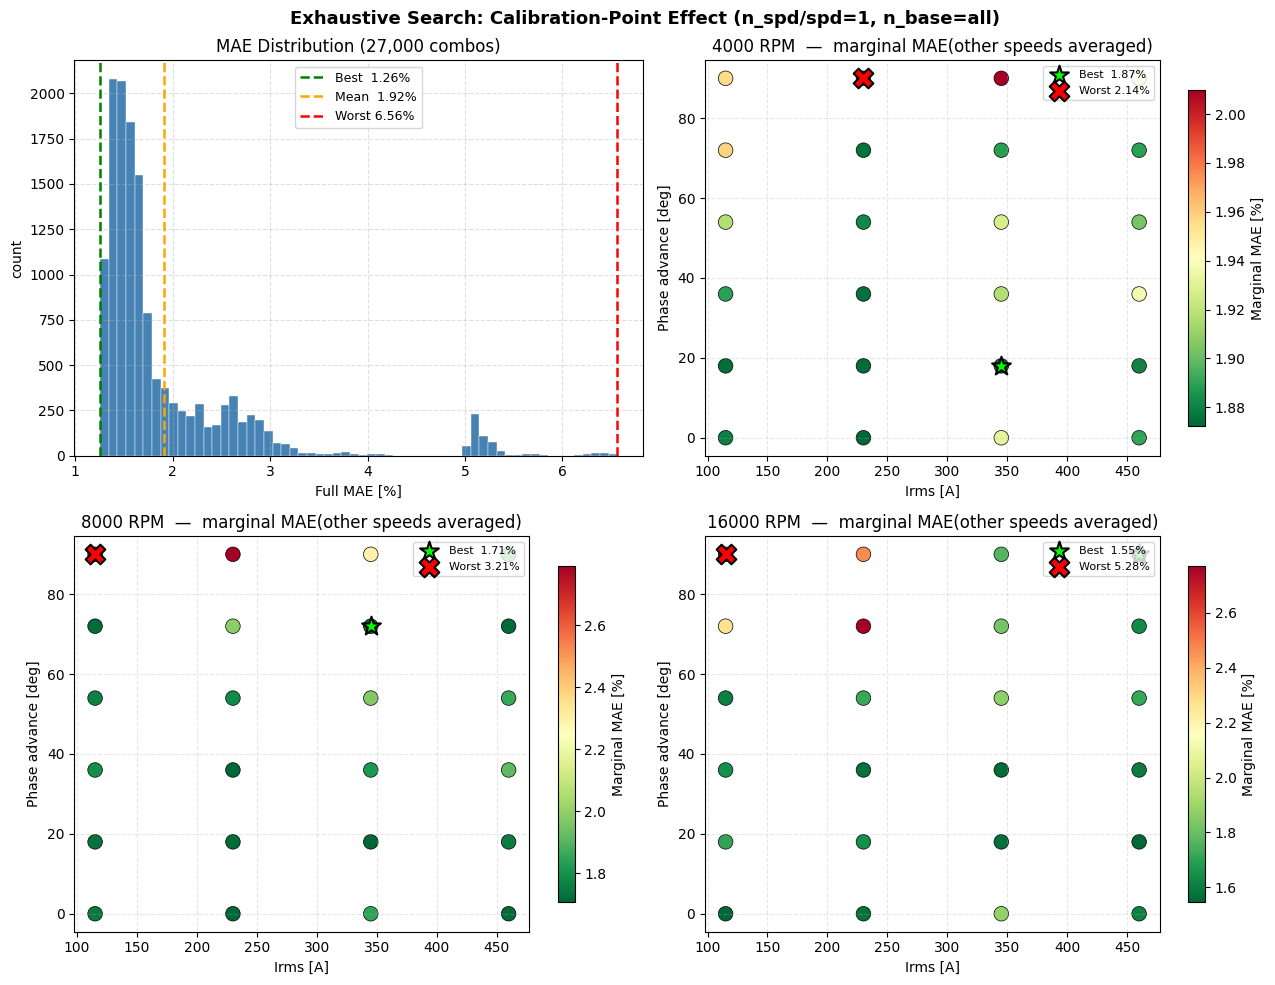

저장: D:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\map_exports\Ref\exhaustive_cal_search_Ref.png
=== Best combination ===
  4000 RPM: Irms=230.0 A  phase=36.0 deg  f_scale=0.939
  8000 RPM: Irms=230.0 A  phase=36.0 deg  f_scale=0.835
  16000 RPM: Irms=460.0 A  phase=90.0 deg  f_scale=0.699
  -> MAE = 1.258%
=== Worst combination ===
  4000 RPM: Irms=230.0 A  phase=90.0 deg  f_scale=0.912
  8000 RPM: Irms=230.0 A  phase=90.0 deg  f_scale=0.787
  16000 RPM: Irms=115.1 A  phase=90.0 deg  f_scale=0.831
  -> MAE = 6.561%


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# [9] Exhaustive Calibration-Point Search  (n_spd/spd = 1, n_base = all)
# ─────────────────────────────────────────────────────────────────────────────
try:
    get_ipython().run_line_magic("matplotlib", "interactive")
except Exception:
    pass

import numpy as np
import matplotlib.pyplot as plt
from itertools import product as iproduct

# ── 1. Base RBF (2 kRPM 전체 포인트) 한 번만 학습 ──────────────────────────────
ib_ex = irms_arr[base_idx]
pb_ex = phase_arr[base_idx]
yb_ex = af_arr[base_idx]
nb_ex = len(base_idx)

Pg_ex = np.zeros((nb_ex, nb_ex))
for j in range(nb_ex):
    r2 = (ib_ex - ib_ex[j])**2/LS_I**2 + (pb_ex - pb_ex[j])**2/LS_P**2
    Pg_ex[:, j] = r2 * np.log(np.sqrt(r2) + 1e-12)
wg_ex = np.linalg.solve(Pg_ex + LAM * np.eye(nb_ex), yb_ex)

def _g_ex(I, th):
    I = np.asarray(I, float); th = np.asarray(th, float)
    I, th = np.broadcast_arrays(I, th)
    orig = I.shape
    Iv, tv = I.ravel()[:, None], th.ravel()[:, None]
    r2 = (Iv - ib_ex)**2/LS_I**2 + (tv - pb_ex)**2/LS_P**2
    return ((r2 * np.log(np.sqrt(r2) + 1e-12)) @ wg_ex).reshape(orig)

# ── 2. 전체 포인트 g값 사전 계산 ──────────────────────────────────────────────
g_all_ex = _g_ex(irms_arr, phase_arr)

# ── 3. 비기준 속도별 스케일링 인수 후보 사전 계산 ──────────────────────────────
other_spds_ex = sorted(other_spds_abl)          # [4.0, 8.0, 16.0]
grp_ex   = {s: spd_groups_abl[s] for s in other_spds_ex}
f_cand_ex = {}
for s in other_spds_ex:
    grp = grp_ex[s]
    f_cand_ex[s] = af_arr[grp] / (g_all_ex[grp] + 1e-12)

sc_ex  = [2.0] + other_spds_ex                  # [2.0, 4.0, 8.0, 16.0]
deg_ex = min(2, len(sc_ex) - 1)
n0, n1, n2 = [len(grp_ex[s]) for s in other_spds_ex]

# ── 4. 전수탐색 ───────────────────────────────────────────────────────────────
print(f"전수탐색: {n0} x {n1} x {n2} = {n0*n1*n2:,} 조합 계산 중...")
mae_grid_ex = np.full((n0, n1, n2), np.nan)

for i, j, k in iproduct(range(n0), range(n1), range(n2)):
    fc = [1.0, float(f_cand_ex[other_spds_ex[0]][i]),
               float(f_cand_ex[other_spds_ex[1]][j]),
               float(f_cand_ex[other_spds_ex[2]][k])]
    pf = np.poly1d(np.polyfit(sc_ex, fc, deg_ex))
    af_pred = pf(speeds_k) * g_all_ex
    mae_grid_ex[i, j, k] = np.abs(
        (h_ac_arr * af_pred - f_ac_arr) / (f_ac_arr + 1e-12) * 100).mean()

print(f"완료  |  MAE 범위: {np.nanmin(mae_grid_ex):.2f}% ~ {np.nanmax(mae_grid_ex):.2f}%  "
      f"(평균 {np.nanmean(mae_grid_ex):.2f}%)")

# ── 5. 시각화 ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Exhaustive Search: Calibration-Point Effect (n_spd/spd=1, n_base=all)",
             fontsize=13, fontweight="bold")

# (a) MAE 히스토그램
ax = axes[0, 0]
ax.hist(mae_grid_ex.ravel(), bins=60, color="steelblue", edgecolor="white", linewidth=0.3)
ax.axvline(np.nanmin(mae_grid_ex),  color="green",  ls="--", lw=1.8,
           label=f"Best  {np.nanmin(mae_grid_ex):.2f}%")
ax.axvline(np.nanmean(mae_grid_ex), color="orange", ls="--", lw=1.8,
           label=f"Mean  {np.nanmean(mae_grid_ex):.2f}%")
ax.axvline(np.nanmax(mae_grid_ex),  color="red",    ls="--", lw=1.8,
           label=f"Worst {np.nanmax(mae_grid_ex):.2f}%")
ax.set_xlabel("Full MAE [%]"); ax.set_ylabel("count")
ax.set_title("MAE Distribution (27,000 combos)"); ax.legend(fontsize=9)
ax.grid(True, ls="--", alpha=0.4)

# (b)(c)(d) 속도별 marginal 히트맵
spd_labels_ex = [f"{int(s*1000)} RPM" for s in other_spds_ex]
marginal_axes  = [axes[0, 1], axes[1, 0], axes[1, 1]]

for ax_idx, (s_target, ax) in enumerate(zip(other_spds_ex, marginal_axes)):
    if ax_idx == 0:   mae_marg = mae_grid_ex.mean(axis=(1, 2))
    elif ax_idx == 1: mae_marg = mae_grid_ex.mean(axis=(0, 2))
    else:             mae_marg = mae_grid_ex.mean(axis=(0, 1))

    grp = grp_ex[s_target]
    irms_v  = irms_arr[grp]
    phase_v = phase_arr[grp]

    sc_plot = ax.scatter(irms_v, phase_v, c=mae_marg, cmap="RdYlGn_r",
                         s=110, edgecolors="k", linewidths=0.5,
                         vmin=np.nanpercentile(mae_marg, 5),
                         vmax=np.nanpercentile(mae_marg, 95))

    best_i  = int(np.nanargmin(mae_marg))
    worst_i = int(np.nanargmax(mae_marg))
    ax.scatter(irms_v[best_i],  phase_v[best_i],  s=200, c="lime", edgecolors="k",
               lw=1.5, marker="*", zorder=5,
               label=f"Best  {mae_marg[best_i]:.2f}%")
    ax.scatter(irms_v[worst_i], phase_v[worst_i], s=200, c="red",  edgecolors="k",
               lw=1.5, marker="X", zorder=5,
               label=f"Worst {mae_marg[worst_i]:.2f}%")

    plt.colorbar(sc_plot, ax=ax, label="Marginal MAE [%]", shrink=0.85)
    ax.set_xlabel("Irms [A]"); ax.set_ylabel("Phase advance [deg]")
    ax.set_title(f"{spd_labels_ex[ax_idx]}  —  marginal MAE(other speeds averaged)")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, ls="--", alpha=0.3)

plt.tight_layout()
out_path = out_dir / f"exhaustive_cal_search_{MODEL_SCALE}.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"저장: {out_path}")

# ── 6. Best / Worst 조합 출력 ─────────────────────────────────────────────────
bi, bj, bk = np.unravel_index(int(np.nanargmin(mae_grid_ex)), mae_grid_ex.shape)
wi, wj, wk = np.unravel_index(int(np.nanargmax(mae_grid_ex)), mae_grid_ex.shape)

print("=== Best combination ===")
for s, idx_loc in zip(other_spds_ex, [bi, bj, bk]):
    gi = grp_ex[s][idx_loc]
    print(f"  {int(s*1000)} RPM: Irms={irms_arr[gi]:.1f} A  "
          f"phase={phase_arr[gi]:.1f} deg  "
          f"f_scale={f_cand_ex[s][idx_loc]:.3f}")
print(f"  -> MAE = {mae_grid_ex[bi, bj, bk]:.3f}%")

print("=== Worst combination ===")
for s, idx_loc in zip(other_spds_ex, [wi, wj, wk]):
    gi = grp_ex[s][idx_loc]
    print(f"  {int(s*1000)} RPM: Irms={irms_arr[gi]:.1f} A  "
          f"phase={phase_arr[gi]:.1f} deg  "
          f"f_scale={f_cand_ex[s][idx_loc]:.3f}")
print(f"  -> MAE = {mae_grid_ex[wi, wj, wk]:.3f}%")


# [10] 좌표계 비교: (Irms, phase) vs (Id, Iq)

동일한 Separable / 3D TPS RBF 구조에서 입력 좌표계만 바꿔 MAE를 비교합니다.
- **현재**: Irms [A] + phase advance [deg]
- **대안**: Id [A] + Iq [A] (데이터 수집 그리드와 동일)


ARD  (Irms/phase): LS_I=128.5 A, LS_P=30.74 deg
ARD  (Id/Iq):      LS_ID=194.4 A, LS_IQ=194.4 A

=== 모델 빌드 중 ===
  Separable  (Irms, phase): Train MAE = 1.328%
  Separable  (Id,   Iq  ): Train MAE = 1.328%
  3D TPS RBF (Irms, phase): Train MAE = 0.000%
  3D TPS RBF (Id,   Iq  ): Train MAE = 0.000%

  LOOCV 계산 중 (Separable 2가지)...
  Separable LOOCV (Irms, phase): 3.135%
  Separable LOOCV (Id,   Iq  ): 3.548%


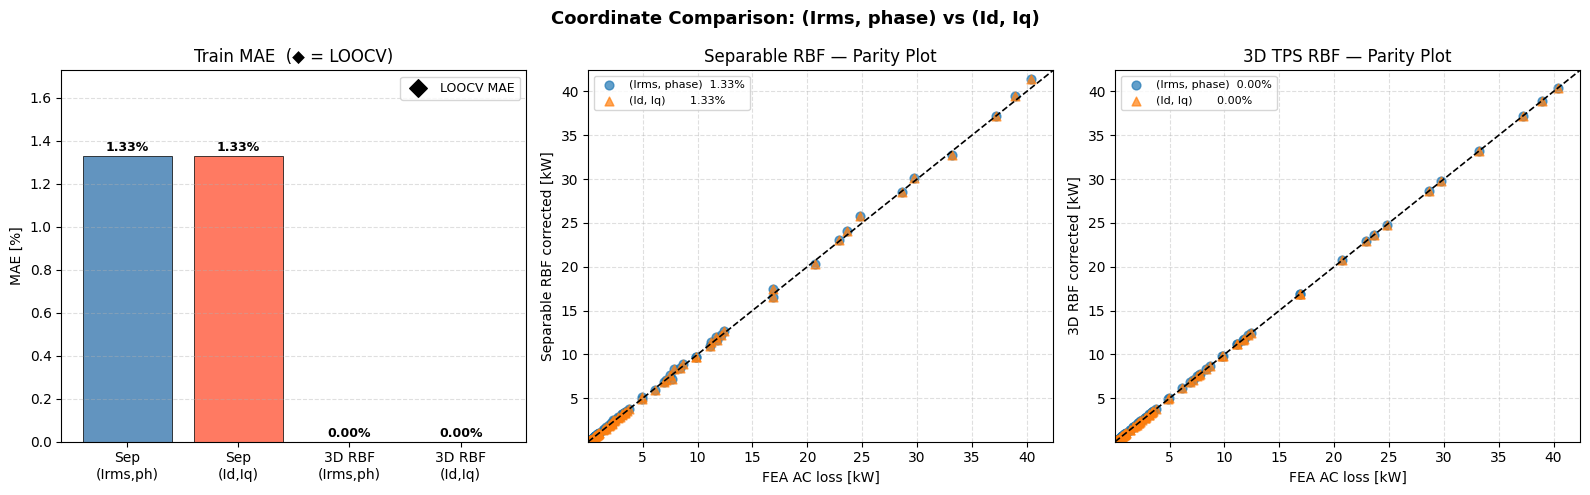

저장: D:\KangDH\EveryMotor\eMach\mlxperPJT\JEET\map_exports\Ref\coord_comparison_Ref.png


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# [10] 좌표계 비교: (Irms, phase advance) vs (Id, Iq)
# ─────────────────────────────────────────────────────────────────────────────
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

import numpy as np
import matplotlib.pyplot as plt

# ── ARD 스케일 ────────────────────────────────────────────────────────────
LS_ID = float(id_arr.std())
LS_IQ = float(iq_arr.std())
print(f'ARD  (Irms/phase): LS_I={LS_I:.1f} A, LS_P={LS_P:.2f} deg')
print(f'ARD  (Id/Iq):      LS_ID={LS_ID:.1f} A, LS_IQ={LS_IQ:.1f} A')

# ── 2D TPS-RBF 커널 ────────────────────────────────────────────────────────
def _k2(x1, x2, c1, c2, l1, l2):
    r2 = (x1 - c1)**2/l1**2 + (x2 - c2)**2/l2**2
    return r2 * np.log(np.sqrt(r2) + 1e-12)

def _k3(s, x1, x2, sc, c1, c2, ls, l1, l2):
    r2 = (s-sc)**2/ls**2 + (x1-c1)**2/l1**2 + (x2-c2)**2/l2**2
    return r2 * np.log(np.sqrt(r2) + 1e-12)

# ── Separable RBF 빌드 ────────────────────────────────────────────────────
def _build_sep(x1b, x2b, yb, l1, l2, x1o, x2o, spdo, afo, x1a, x2a):
    nb_ = len(x1b)
    Phi = np.zeros((nb_, nb_))
    for j in range(nb_):
        Phi[:, j] = _k2(x1b, x2b, x1b[j], x2b[j], l1, l2)
    w = np.linalg.solve(Phi + LAM * np.eye(nb_), yb)

    def _g(a, b):
        a, b = np.asarray(a, float), np.asarray(b, float)
        a, b = np.broadcast_arrays(a, b)
        orig = a.shape
        av, bv = a.ravel()[:, None], b.ravel()[:, None]
        r2 = (av - x1b)**2/l1**2 + (bv - x2b)**2/l2**2
        return ((r2 * np.log(np.sqrt(r2) + 1e-12)) @ w).reshape(orig)

    f_by = {2.0: [1.0]}
    for idx in range(len(spdo)):
        gv = float(_g(x1o[idx], x2o[idx]))
        f_by.setdefault(spdo[idx], []).append(afo[idx] / (gv + 1e-12))
    sc_ = sorted(f_by.keys())
    fc_ = [np.mean(f_by[s]) for s in sc_]
    pf  = np.poly1d(np.polyfit(sc_, fc_, min(2, len(sc_) - 1)))

    g_all  = _g(x1a, x2a)
    af_pred = pf(speeds_k) * g_all
    err = np.abs((h_ac_arr * af_pred - f_ac_arr) / (f_ac_arr + 1e-12) * 100)
    return af_pred, float(err.mean())

# ── 3D TPS RBF 빌드 ───────────────────────────────────────────────────────
def _build_3d(x1, x2, y, l1, l2):
    n_ = len(x1)
    Phi = np.zeros((n_, n_))
    for j in range(n_):
        Phi[:, j] = _k3(speeds_k, x1, x2, speeds_k[j], x1[j], x2[j], LS_S, l1, l2)
    w = np.linalg.solve(Phi + LAM * np.eye(n_), y)

    def _pred(spd_rpm, a, b):
        s   = np.asarray(spd_rpm, float) / 1000.
        a_  = np.asarray(a, float); b_ = np.asarray(b, float)
        s, a_, b_ = np.broadcast_arrays(s, a_, b_)
        orig = s.shape
        sv, av, bv = s.ravel()[:, None], a_.ravel()[:, None], b_.ravel()[:, None]
        r2 = (sv-speeds_k)**2/LS_S**2 + (av-x1)**2/l1**2 + (bv-x2)**2/l2**2
        return ((r2 * np.log(np.sqrt(r2) + 1e-12)) @ w).reshape(orig)

    af_pred = _pred(speeds_k * 1000, x1, x2)
    err = np.abs((h_ac_arr * af_pred - f_ac_arr) / (f_ac_arr + 1e-12) * 100)
    return af_pred, float(err.mean()), _pred

# ── LOOCV (Separable) ─────────────────────────────────────────────────────
def _loocv_sep(x1a, x2a, l1, l2):
    bm0 = np.abs(speeds_k - 2.0) < 0.1
    errs = []
    for i in range(n):
        bm = bm0.copy(); bm[i] = False
        x1b_ = x1a[bm]; x2b_ = x2a[bm]; yb_ = af_arr[bm]
        nb_ = len(x1b_)
        Phi = np.zeros((nb_, nb_))
        for j in range(nb_):
            Phi[:, j] = _k2(x1b_, x2b_, x1b_[j], x2b_[j], l1, l2)
        try:
            w_ = np.linalg.solve(Phi + LAM * np.eye(nb_), yb_)
        except np.linalg.LinAlgError:
            continue

        def _g_(a, b, xb1=x1b_, xb2=x2b_, ww=w_):
            av, bv = np.asarray(a, float).ravel()[:, None], np.asarray(b, float).ravel()[:, None]
            r2 = (av - xb1)**2/l1**2 + (bv - xb2)**2/l2**2
            return float(((r2 * np.log(np.sqrt(r2) + 1e-12)) @ ww)[0])

        om_idx = np.where(~bm0)[0]; om_idx = om_idx[om_idx != i]
        f_by_ = {2.0: [1.0]}
        for ii in om_idx:
            gv = _g_(x1a[ii], x2a[ii])
            f_by_.setdefault(speeds_k[ii], []).append(af_arr[ii] / (gv + 1e-12))
        sc_ = sorted(f_by_.keys())
        if len(sc_) < 2: continue
        fc_ = [np.mean(f_by_[s]) for s in sc_]
        pf_ = np.poly1d(np.polyfit(sc_, fc_, min(2, len(sc_) - 1)))
        gv_i = _g_(x1a[i], x2a[i])
        af_i  = pf_(speeds_k[i]) * gv_i
        errs.append(abs((h_ac_arr[i]*af_i - f_ac_arr[i]) / (f_ac_arr[i]+1e-12) * 100))
    return float(np.mean(errs)) if errs else np.nan

# ── 데이터 슬라이스 ────────────────────────────────────────────────────────
not_base = ~(np.abs(speeds_k - 2.0) < 0.1)
spdo = speeds_k[not_base]
afo  = af_arr[not_base]

# ── 4가지 모델 빌드 ────────────────────────────────────────────────────────
print('\n=== 모델 빌드 중 ===')
af_sep_ip, mae_sep_ip = _build_sep(
    irms_arr[base_idx], phase_arr[base_idx], af_arr[base_idx], LS_I,  LS_P,
    irms_arr[not_base], phase_arr[not_base], spdo, afo, irms_arr, phase_arr)

af_sep_dq, mae_sep_dq = _build_sep(
    id_arr[base_idx],   iq_arr[base_idx],   af_arr[base_idx], LS_ID, LS_IQ,
    id_arr[not_base],   iq_arr[not_base],   spdo, afo, id_arr, iq_arr)

af_3d_ip, mae_3d_ip, _ = _build_3d(irms_arr, phase_arr, af_arr, LS_I,  LS_P)
af_3d_dq, mae_3d_dq, _ = _build_3d(id_arr,   iq_arr,   af_arr, LS_ID, LS_IQ)

print(f'  Separable  (Irms, phase): Train MAE = {mae_sep_ip:.3f}%')
print(f'  Separable  (Id,   Iq  ): Train MAE = {mae_sep_dq:.3f}%')
print(f'  3D TPS RBF (Irms, phase): Train MAE = {mae_3d_ip:.3f}%')
print(f'  3D TPS RBF (Id,   Iq  ): Train MAE = {mae_3d_dq:.3f}%')

print('\n  LOOCV 계산 중 (Separable 2가지)...')
cv_sep_ip = _loocv_sep(irms_arr, phase_arr, LS_I,  LS_P)
cv_sep_dq = _loocv_sep(id_arr,   iq_arr,   LS_ID, LS_IQ)
print(f'  Separable LOOCV (Irms, phase): {cv_sep_ip:.3f}%')
print(f'  Separable LOOCV (Id,   Iq  ): {cv_sep_dq:.3f}%')

# ── 시각화 ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Coordinate Comparison: (Irms, phase) vs (Id, Iq)',
             fontsize=13, fontweight='bold')

# (a) MAE 막대 그래프
ax = axes[0]
labels = ['Sep\n(Irms,ph)', 'Sep\n(Id,Iq)', '3D RBF\n(Irms,ph)', '3D RBF\n(Id,Iq)']
train  = [mae_sep_ip, mae_sep_dq, mae_3d_ip, mae_3d_dq]
colors = ['steelblue', 'tomato', 'steelblue', 'tomato']
bars   = ax.bar(labels, train, color=colors, edgecolor='k', linewidth=0.6, alpha=0.85)
ax.scatter([0, 1], [cv_sep_ip, cv_sep_dq], s=80, color='black',
           zorder=5, marker='D', label='LOOCV MAE')
for bar, v in zip(bars, train):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.2f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('MAE [%]'); ax.set_title('Train MAE  (◆ = LOOCV)')
ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.4, axis='y')
ax.set_ylim(0, max(train) * 1.3)

# (b) Separable 패리티 플롯
ax = axes[1]
lim = [f_ac_arr.min()*0.92, f_ac_arr.max()*1.05]
ax.scatter(f_ac_arr, h_ac_arr*af_sep_ip, s=40, alpha=0.7, marker='o',
           label=f'(Irms, phase)  {mae_sep_ip:.2f}%')
ax.scatter(f_ac_arr, h_ac_arr*af_sep_dq, s=40, alpha=0.7, marker='^',
           label=f'(Id, Iq)       {mae_sep_dq:.2f}%')
ax.plot(lim, lim, 'k--', lw=1.2)
ax.set_xlabel('FEA AC loss [kW]'); ax.set_ylabel('Separable RBF corrected [kW]')
ax.set_title('Separable RBF — Parity Plot'); ax.legend(fontsize=8)
ax.grid(True, ls='--', alpha=0.4); ax.set_xlim(lim); ax.set_ylim(lim)

# (c) 3D RBF 패리티 플롯
ax = axes[2]
ax.scatter(f_ac_arr, h_ac_arr*af_3d_ip, s=40, alpha=0.7, marker='o',
           label=f'(Irms, phase)  {mae_3d_ip:.2f}%')
ax.scatter(f_ac_arr, h_ac_arr*af_3d_dq, s=40, alpha=0.7, marker='^',
           label=f'(Id, Iq)       {mae_3d_dq:.2f}%')
ax.plot(lim, lim, 'k--', lw=1.2)
ax.set_xlabel('FEA AC loss [kW]'); ax.set_ylabel('3D RBF corrected [kW]')
ax.set_title('3D TPS RBF — Parity Plot'); ax.legend(fontsize=8)
ax.grid(True, ls='--', alpha=0.4); ax.set_xlim(lim); ax.set_ylim(lim)

plt.tight_layout()
out_path = out_dir / f'coord_comparison_{MODEL_SCALE}.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {out_path}')
